# EDA (Exploratory Data Analysis) — E1 Conservative Strategy (GRU, 90 days)

Exploratory data analysis for the long-term conservative strategy.

**Tickers**: 5 Argentine (.BA) + 5 US  
**Horizon**: 90 days  
**Model**: GRU  
**Features**: 13 technical indicators  
**Data**: daily OHLCV (~10 years)


## 0. Setup

In [22]:
import sys
from pathlib import Path

# Add the project root to the path so modules under src/ can be imported.
# This notebook lives in notebooks/eda/, so we go up 2 levels (../../).
ROOT = Path("../..").resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# --- Data and plotting libraries ---
import numpy as np       # Numeric operations (log, arrays, etc.)
import pandas as pd      # DataFrames for tabular data
import matplotlib.pyplot as plt  # Base plotting
import seaborn as sns    # Statistical plots (heatmaps, boxplots, etc.)
from scipy import stats  # Statistical tests (Jarque-Bera, Q-Q, Pearson, etc.)
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf  # Autocorrelation
from statsmodels.tsa.stattools import adfuller  # ADF stationarity test

# --- Project modules ---
from src.utils import project_root, load_yaml              # Helpers: project root, YAML loading
from src.e1.build_features_eda import compute_e1_features, make_target_e1  # Legacy version kept for EDA evidence
from src.e1.train_pipeline import load_ohlcv_csv           # CSV loading with timestamp parsing
from src.data.clean_daily import diagnose_data_quality      # Data quality diagnostics

# --- Global plot style ---
sns.set_theme(style="whitegrid", palette="muted")  # Soft grid background, muted colors
plt.rcParams["figure.figsize"] = (14, 6)           # Default figure size
plt.rcParams["figure.dpi"] = 100                   # Screen resolution

print(f"Project root: {ROOT}")


Raíz del proyecto: /Users/sebastiancarreras/Documents/Education/Posgrado_AI_FIUBA/proyecto_final/trading_predict


In [23]:
# --- Load the central project configuration ---
# base.yaml holds every parameter: tickers, horizon, lookback, model, etc.
cfg = load_yaml(project_root() / "src" / "config" / "base.yaml")

# Pull the list of 10 tickers assigned to the E1 strategy
E1_TICKERS = cfg["universe"]["tickers_by_strategy"]["e1_conservative"]

# Pull the E1 strategy parameters
E1_CFG = cfg["strategies"]["e1_conservative"]
HORIZON = E1_CFG["horizon_days"]   # 90 days: how far into the future we predict
LOOKBACK = E1_CFG["lookback_days"] # 360 days: how much history the model sees as input

# --- Split tickers by market ---
# Argentine tickers end in ".BA" (Buenos Aires)
AR_TICKERS = [t for t in E1_TICKERS if t.endswith(".BA")]
US_TICKERS = [t for t in E1_TICKERS if not t.endswith(".BA")]

print(f"E1 tickers: {E1_TICKERS}")
print(f"  AR ({len(AR_TICKERS)}): {AR_TICKERS}")
print(f"  US ({len(US_TICKERS)}): {US_TICKERS}")
print(f"Horizon: {HORIZON} days | Lookback: {LOOKBACK} days")


Tickers E1: ['YPFD.BA', 'GGAL.BA', 'PAMP.BA', 'BYMA.BA', 'CEPU.BA', 'AAPL', 'MSFT', 'JNJ', 'PG', 'V']
  AR (5): ['YPFD.BA', 'GGAL.BA', 'PAMP.BA', 'BYMA.BA', 'CEPU.BA']
  US (5): ['AAPL', 'MSFT', 'JNJ', 'PG', 'V']
Horizonte: 90 días | Lookback: 360 días


In [41]:
# --- Load frozen OHLCV data for the EDA (reproducible snapshot) ---
# Goal: make the EDA 100% reproducible across runs.
# Rule: the local snapshot is created ONCE and everything reads from it afterwards.

import hashlib
import json
import shutil
from datetime import datetime, timezone

source_clean_dir = project_root() / "data" / "clean"
snapshot_root = project_root() / "data" / "snapshots" / "e1_conservative_eda_v1"
manifest_path = snapshot_root / "manifest.json"

def _sha256_file(path: Path) -> str:
    h = hashlib.sha256()
    with path.open("rb") as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b""):
            h.update(chunk)
    return h.hexdigest()

# Create the snapshot only if it does not exist. Once created it stays fixed for the EDA.
if not snapshot_root.exists():
    snapshot_root.mkdir(parents=True, exist_ok=True)
    print(f"[SNAPSHOT] Creating reproducible snapshot at: {snapshot_root}")

    file_records = []
    for ticker in E1_TICKERS:
        src = source_clean_dir / f"{ticker}_daily.csv"
        dst = snapshot_root / f"{ticker}_daily.csv"

        if not src.exists():
            raise FileNotFoundError(f"No source CSV for {ticker}: {src}")

        shutil.copy2(src, dst)
        df_tmp = load_ohlcv_csv(dst)
        file_records.append({
            "ticker": ticker,
            "file": dst.name,
            "rows": int(len(df_tmp)),
            "start": df_tmp.index.min().strftime("%Y-%m-%d"),
            "end": df_tmp.index.max().strftime("%Y-%m-%d"),
            "sha256": _sha256_file(dst),
        })

    manifest = {
        "snapshot_name": "e1_conservative_eda_v1",
        "created_at_utc": datetime.now(timezone.utc).isoformat(),
        "strategy": "e1_conservative",
        "horizon_days": HORIZON,
        "lookback_days": LOOKBACK,
        "tickers": E1_TICKERS,
        "files": file_records,
    }
    manifest_path.write_text(json.dumps(manifest, indent=2), encoding="utf-8")
    print(f"[SNAPSHOT] Manifest saved: {manifest_path}")
else:
    print(f"[SNAPSHOT] Using existing snapshot: {snapshot_root}")
    if manifest_path.exists():
        print(f"[SNAPSHOT] Manifest: {manifest_path}")
    else:
        print("[SNAPSHOT] Warning: manifest.json not found")

# ALWAYS load from the snapshot (fixed dataset).
data = {}  # Dictionary {ticker: OHLCV_DataFrame}
for ticker in E1_TICKERS:
    path = snapshot_root / f"{ticker}_daily.csv"
    if path.exists():
        data[ticker] = load_ohlcv_csv(path)
        print(f"  {ticker}: {len(data[ticker]):,} days "
              f"| {data[ticker].index.min().date()} -> {data[ticker].index.max().date()}")
    else:
        raise FileNotFoundError(f"Missing snapshot file for {ticker}: {path}")

print(f"\nTickers loaded from snapshot: {len(data)}/{len(E1_TICKERS)}")


[SNAPSHOT] Usando snapshot existente: /Users/sebastiancarreras/Documents/Education/Posgrado_AI_FIUBA/proyecto_final/trading_predict/data/snapshots/e1_conservative_eda_v1
[SNAPSHOT] Manifest: /Users/sebastiancarreras/Documents/Education/Posgrado_AI_FIUBA/proyecto_final/trading_predict/data/snapshots/e1_conservative_eda_v1/manifest.json
  YPFD.BA: 2,431 días | 2016-03-07 -> 2026-03-02
  GGAL.BA: 2,432 días | 2016-03-07 -> 2026-03-02
  PAMP.BA: 2,432 días | 2016-03-07 -> 2026-03-02
  BYMA.BA: 2,113 días | 2017-06-26 -> 2026-03-03
  CEPU.BA: 2,396 días | 2016-03-03 -> 2026-03-03
  AAPL: 2,514 días | 2016-03-03 -> 2026-03-03
  MSFT: 2,514 días | 2016-03-03 -> 2026-03-03
  JNJ: 2,514 días | 2016-03-03 -> 2026-03-03
  PG: 2,514 días | 2016-03-03 -> 2026-03-03
  V: 2,514 días | 2016-03-03 -> 2026-03-03

Tickers cargados desde snapshot: 10/10


---
## 1. Raw Data — Panoramic View


### 1.1 Data quality


In [25]:
# --- Technical profile of each series: descriptive stats + tests ---
# Before building features we need to know what data we are working with. This
# table answers three questions that shape the whole E1 pipeline:
#   1) Is there enough history? With a 90-day horizon, a short or gap-ridden
#      ticker leaves very few trainable windows for the GRU.
#   2) What scale and volatility does each asset have? Argentine .BA and US
#      tickers live in different orders of magnitude -> justifies per-ticker
#      normalization.
#   3) Do the statistical assumptions hold? Prices are not stationary, returns
#      are, and neither is normal. Worth documenting.

summary_rows = []

for ticker, df_t in data.items():
    close = df_t["close"]

    # Daily log return: log(P_t / P_{t-1}).
    # We use log returns instead of simple returns because they are additive
    # over time (summing 90 log returns = the 90-day log return, which is
    # exactly the E1 target) and their distribution is more symmetric and stable.
    log_ret = np.log(close / close.shift(1)).dropna()

    row = {
        "Ticker": ticker,

        # --- Time coverage ---
        # How many daily bars exist and what range they span. Useful to spot
        # recently listed tickers or incomplete downloads, and to check whether
        # every asset shares a comparable common period.
        "Records": len(df_t),
        "Start": df_t.index.min().strftime("%Y-%m-%d"),
        "End": df_t.index.max().strftime("%Y-%m-%d"),

        # --- Price level ---
        # Not used to decide signals (price is not stationary: its mean drifts
        # over time), but they size up the asset and expose data errors:
        # unadjusted splits, zeros, absurd jumps (a max/min far away from the
        # mean is the first red flag).
        "Close (mean)": close.mean(),
        "Close (std)": close.std(),
        "Close (min)": close.min(),
        "Close (max)": close.max(),

        # --- Return distribution ---
        # mean: daily drift. Usually ~0; a large value means the asset trended
        #   hard over the period (careful about extrapolating it forward).
        # std:  daily volatility. It is the yardstick for judging whether the
        #   90d return the model predicts is real signal or accumulated noise.
        # skew: asymmetry. Negative = sharp drops are more frequent or more
        #   severe than rallies -> risk is not symmetric.
        # kurt: excess kurtosis (pandas already subtracts 3, so 0 = normal).
        #   >0 = fat tails: far more extreme events than a Gaussian predicts.
        #   Motivates robust metrics and distrust of confidence intervals that
        #   assume normality.
        "LogRet (mean)": log_ret.mean(),
        "LogRet (std)": log_ret.std(),
        "LogRet (skew)": log_ret.skew(),
        "LogRet (kurt)": log_ret.kurt(),
    }

    # --- Jarque-Bera test: are the returns normal? ---
    # It combines skewness (S) and kurtosis (K) into a single statistic:
    #   JB = n/6 * (S^2 + K^2/4),  with K = excess kurtosis.
    # H0 = the distribution is normal. p < 0.05 -> reject H0 -> NOT normal.
    # In finance the p-value is ~0 almost always; the value of running it is
    # leaving numerical evidence that the fat tails are there and that any
    # Gaussian assumption downstream (loss, VaR, intervals) is weak.
    # With fewer than ~8 observations the statistic is unreliable -> NaN.
    if len(log_ret) >= 8:
        jb_stat, jb_p = stats.jarque_bera(log_ret)
        row["JB stat"] = jb_stat   # Higher = further from normal
        row["JB p-val"] = jb_p     # p < 0.05 -> not normal
    else:
        row["JB stat"] = np.nan
        row["JB p-val"] = np.nan

    # --- ADF test (Augmented Dickey-Fuller): is the series stationary? ---
    # H0 = the series has a unit root, i.e. it is NOT stationary (it behaves
    # like a random walk: mean and variance change over time).
    # p < 0.05 -> reject H0 -> the series IS stationary.
    # It is applied to returns, not to price: price almost always has a unit
    # root (high p) and returns almost always reject it (p ~ 0). Confirming
    # this matters because the model learns from return-derived features: if
    # their mean/variance drifted over time, what was learned on train would
    # not hold on test (distributions would not be comparable).
    # autolag="AIC" picks how many lags to include by minimizing the AIC.
    if len(log_ret) >= 20:
        adf_result = adfuller(log_ret, autolag="AIC")
        row["ADF stat"] = adf_result[0]   # More negative = stronger evidence against the unit root
        row["ADF p-val"] = adf_result[1]  # p < 0.05 -> stationary
    else:
        row["ADF stat"] = np.nan
        row["ADF p-val"] = np.nan

    # --- Gaps: holes in the trading calendar ---
    # time_deltas = distance between consecutive timestamps. On daily data the
    # median is 1 day (the Friday->Monday jump being the normal exception), so
    # we flag as a gap any jump larger than 3x the median: long holidays,
    # trading halts (common on .BA names) or incomplete downloads.
    # It matters because the GRU windows assume consecutive steps: a large gap
    # injects an artificial price jump inside the window and contaminates both
    # the features and the 90-day target. "Max gap" tells us whether it is
    # tolerable (a holiday) or whether the history should be trimmed from there.
    time_deltas = df_t.index.to_series().diff().dropna()
    if len(time_deltas) > 0:
        median_delta = time_deltas.median()
        gaps = time_deltas[time_deltas > median_delta * 3]
        row["Gaps (>3x median)"] = len(gaps)   # How many holes there are
        if len(gaps) > 0:
            row["Max gap (days)"] = gaps.max().days  # How bad the worst one is
        else:
            row["Max gap (days)"] = 0
    else:
        row["Gaps (>3x median)"] = 0
        row["Max gap (days)"] = 0

    summary_rows.append(row)

# One row per ticker: read horizontally it is each asset's profile, read
# vertically it compares markets (AR vs US) on volatility, tails and gaps.
summary_df = pd.DataFrame(summary_rows)
display(summary_df.style.set_caption("Statistics per ticker — E1 Conservative"))


,Ticker,Registros,Inicio,Fin,Close (media),Close (std),Close (min),Close (max),LogRet (media),LogRet (std),LogRet (skew),LogRet (kurt),JB stat,JB p-val,ADF stat,ADF p-val,Gaps (>3x mediana),Gap máximo (días)
0,YPFD.BA,2431,2016-03-07,2026-03-02,9447.582188,16049.358089,233.000000,59700.000000,0.002143,0.033619,-0.039010,9.869131,9816.900145,0.000000,-46.516898,0.000000,212,7
1,GGAL.BA,2432,2016-03-07,2026-03-02,1406.656723,2441.873235,37.200000,9195.000000,0.002056,0.036657,-2.142233,40.977148,171219.663314,0.000000,-15.645139,0.000000,209,7
2,PAMP.BA,2432,2016-03-07,2026-03-02,906.168524,1463.360086,11.300000,5620.000000,0.002430,0.033258,-2.155789,44.533603,201919.283775,0.000000,-37.866930,0.000000,213,7
3,BYMA.BA,2113,2017-06-26,2026-03-03,56.362308,84.824876,1.145812,341.000000,0.002576,0.032420,-2.170318,49.612550,217210.890615,0.000000,-12.414310,0.000000,88,7
4,CEPU.BA,2396,2016-03-03,2026-03-03,400.481851,637.644707,0.863025,2745.000000,0.003244,0.056845,20.060850,757.480030,57179439.334689,0.000000,-46.909509,0.000000,103,55
5,AAPL,2514,2016-03-03,2026-03-03,118.118217,74.693418,20.584816,285.922455,0.000970,0.018196,-0.083411,6.805558,4829.879999,0.000000,-16.315083,0.000000,68,4
6,MSFT,2514,2016-03-03,2026-03-03,228.591152,140.197700,42.911076,539.825195,0.000864,0.016934,-0.267801,8.289766,7192.858366,0.000000,-17.029667,0.000000,68,4
7,JNJ,2514,2016-03-03,2026-03-03,131.762662,28.560875,80.679779,248.559998,0.000445,0.011543,-0.457997,10.206655,10947.396308,0.000000,-12.320884,0.000000,68,4
8,PG,2514,2016-03-03,2026-03-03,113.252158,34.558222,57.956532,173.840225,0.000372,0.011822,-0.082008,11.046199,12722.897160,0.000000,-16.302242,0.000000,68,4
9,V,2514,2016-03-03,2026-03-03,194.105407,79.485144,65.462563,371.152252,0.000612,0.015312,-0.153366,10.281673,11029.744393,0.000000,-13.639117,0.000000,68,4


### 1.2 Missing data heatmap

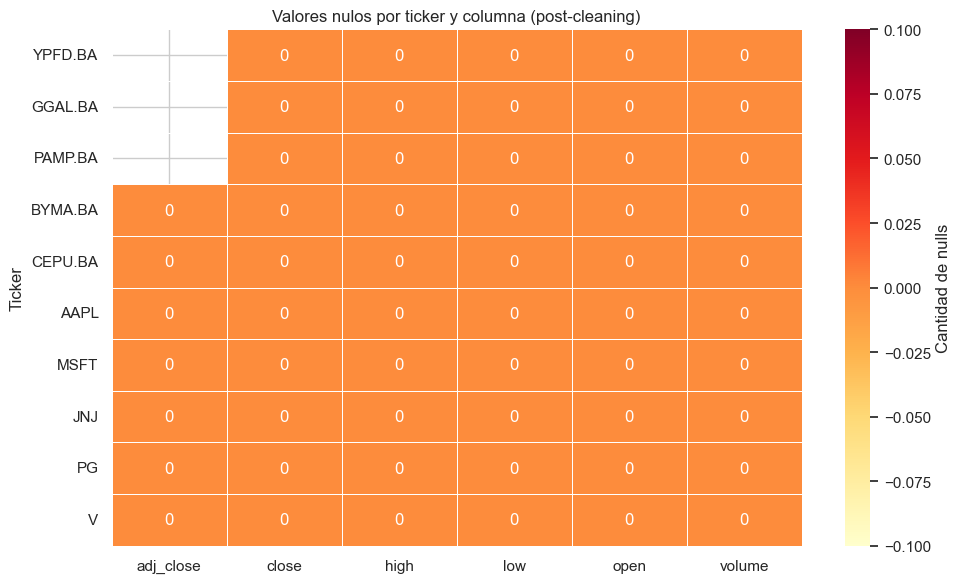

In [26]:
# --- Null value heatmap ---
# We build a matrix where each row is a ticker and each column an OHLCV field.
# Each cell holds the number of nulls. Ideally everything should be 0 after the
# cleaning process (forward fill).
null_matrix = pd.DataFrame({
    ticker: df.isna().sum()   # Count nulls per column for each ticker
    for ticker, df in data.items()
}).T  # Transpose: rows=tickers, columns=OHLCV fields

fig, ax = plt.subplots(figsize=(10, 6))
# annot=True: print the number inside each cell
# fmt=".0f": no decimals
# cmap="YlOrRd": yellow -> orange -> red scale (redder = more nulls)
sns.heatmap(null_matrix, annot=True, fmt=".0f", cmap="YlOrRd", ax=ax,
            linewidths=0.5, cbar_kws={"label": "Number of nulls"})
ax.set_title("Null values by ticker and column (post-cleaning)")
ax.set_ylabel("Ticker")
plt.tight_layout()
plt.show()


**Analysis — Data quality**

The post-cleaning data shows good overall quality:

- **Time coverage**: US tickers have ~2,515 days (~10 full years, since Feb-2016). AR tickers range from 2,109 (BYMA.BA, listed since Jun-2017) to 2,433 days. That is enough for walk-forward with 5 folds.
- **No nulls and no duplicates** after the cleaning process (forward fill). The heatmap should confirm 0 nulls across every column.
- **Gaps**: some AR tickers may show more gaps >4 days due to extra Argentine holidays and market halts. This is expected and does not affect modelling since we work with daily data (not intraday).

**Implication for the model**: the ~300-400 day difference between BYMA.BA and the US tickers means BYMA will have fewer training samples per walk-forward fold, which could hurt its performance.


### 1.3 Normalized price series (base 100)


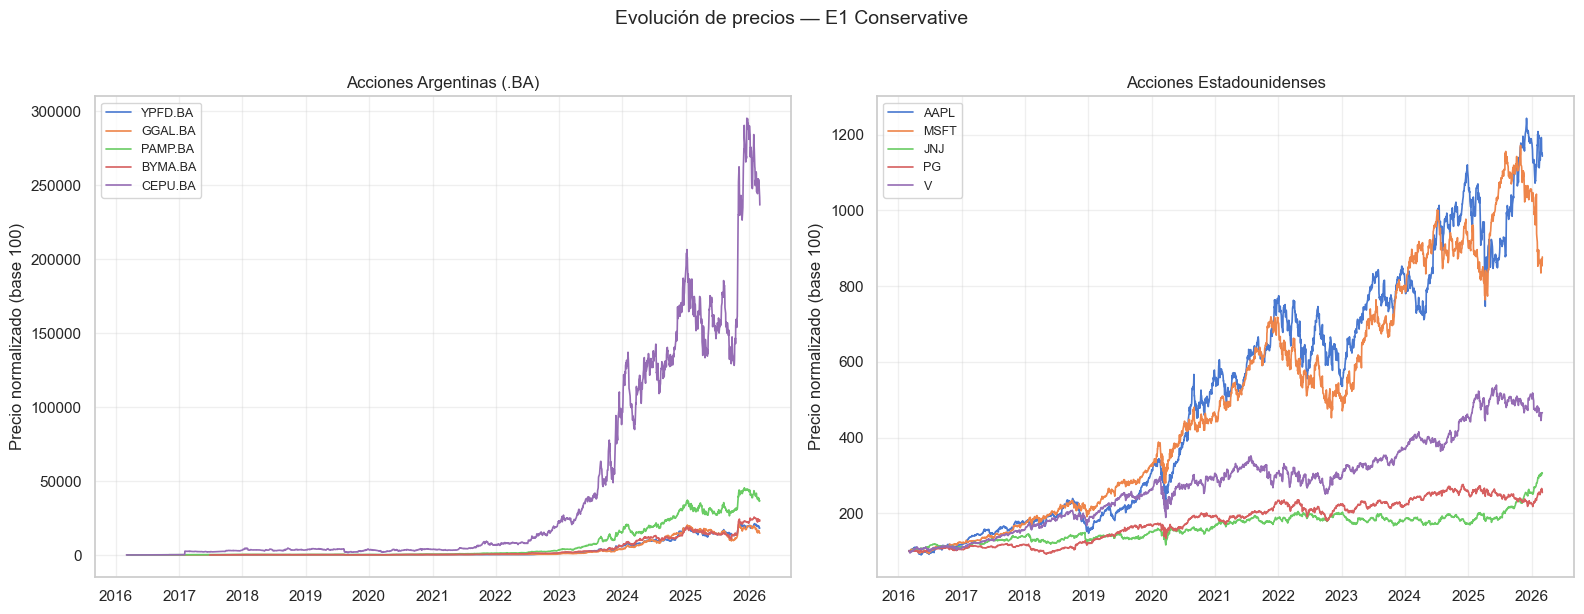

In [27]:
# --- Normalized price series (base 100) ---
# Normalizing = divide every price by the first day's price and multiply by 100.
# That way all of them start at 100 and we can compare "how much each stock grew"
# on the same chart, no matter whether one trades at $5 and another at $500.
# We split into 2 panels (AR vs US) because the scales are so different that in
# a single chart the US names would be invisible next to the AR ones.

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=False)  # sharey=False: each panel keeps its own Y scale

for ax, tickers, title in [
    (axes[0], AR_TICKERS, "Argentine stocks (.BA)"),
    (axes[1], US_TICKERS, "US stocks"),
]:
    for ticker in tickers:
        if ticker not in data:
            continue
        close = data[ticker]["close"]
        # Base-100 normalization: price(t) / price(t=0) * 100
        # Reaching 200 means the value doubled since the start
        normalized = 100 * close / close.iloc[0]
        ax.plot(normalized.index, normalized.values, label=ticker, linewidth=1.2)
    ax.set_title(title)
    ax.set_ylabel("Normalized price (base 100)")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

fig.suptitle("Price evolution — E1 Conservative", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


**Analysis — Normalized prices**

The price evolution reveals two very different universes:

- **Argentine market**: significantly larger cumulative returns (the .BA tickers start at base 100 and reach values in the thousands: percentage relative to the start). This reflects the **devaluation of the Argentine peso**: ARS prices rise nominally even when real value stays flat or falls. GGAL.BA and YPFD.BA show the most volatile paths, with deep drawdowns followed by explosive recoveries.
- **US market**: more moderate and stable returns. AAPL and MSFT lead with sustained growth. PG (consumer staples) and JNJ (health care) show more conservative paths, consistent with their defensive profile. V sits in between.

**Implication for the model**: return scales are radically different across markets. This justifies per-ticker Z-score normalization (not pooled) during training, so the model is not dominated by the nominal magnitude of the Argentine tickers.


### 1.4 Daily return distribution


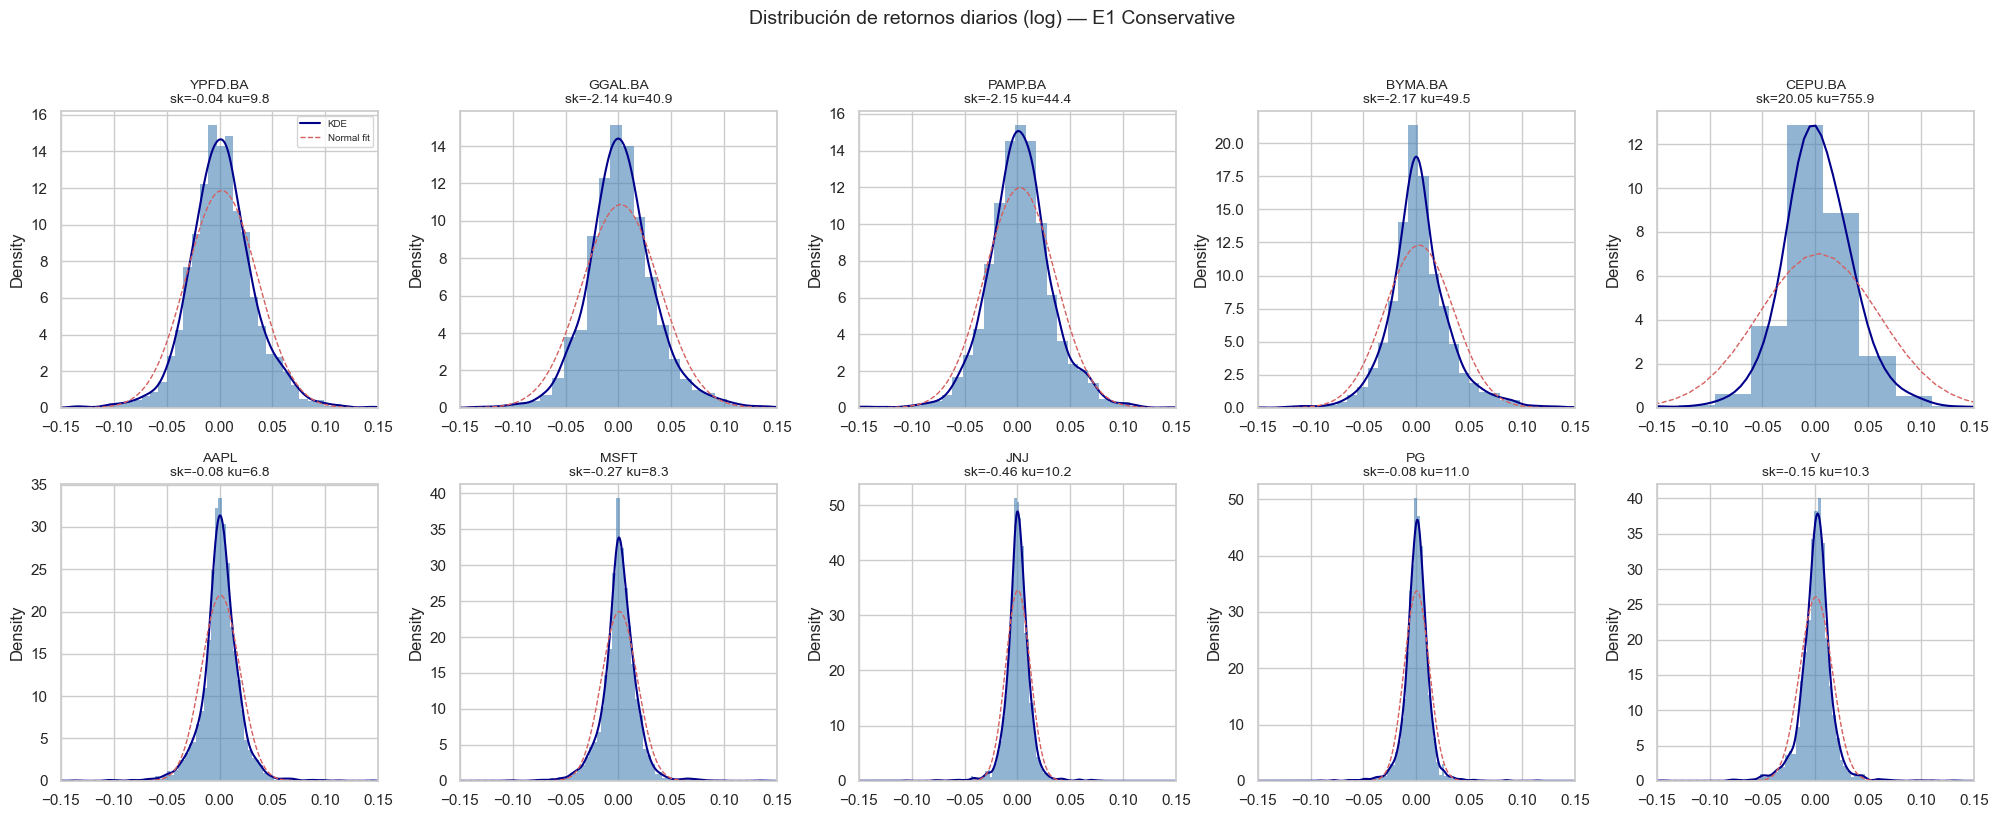

In [28]:
# --- Daily (log) return histograms with KDE and normal fit ---
# For each ticker we overlay 3 layers:
#   1. Histogram: bars showing how often each return range occurs
#   2. KDE (Kernel Density Estimation): smoothed curve estimating the real distribution
#   3. Normal fit: Gaussian bell with the same mean and std, for comparison

# Grid of 2 rows x 5 columns = 10 subplots (one per ticker)
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()  # Turn the 2D axes matrix into a 1D list for easy iteration

for i, ticker in enumerate(E1_TICKERS):
    if ticker not in data:
        continue
    ax = axes[i]

    # Daily log return = ln(price_today) - ln(price_yesterday) = ln(price_today / price_yesterday)
    # .diff() takes the difference with the previous day. .dropna() removes the first NaN.
    # Example: if price goes from $100 to $102, log_ret = ln(102/100) ~ 0.02 (~2%)
    log_ret = np.log(data[ticker]["close"]).diff().dropna()

    # Layer 1: histogram with 80 bins
    # density=True normalizes so the total area is 1 (probability, not counts)
    ax.hist(log_ret, bins=80, density=True, alpha=0.6, color="steelblue", edgecolor="none")

    # Layer 2: KDE (Kernel Density Estimation) - the "smoothed" version of the
    # histogram (like a histogram with infinitely many bins)
    log_ret.plot.kde(ax=ax, color="darkblue", linewidth=1.5, label="KDE")

    # Layer 3: theoretical normal curve with the same mean (mu) and standard deviation (sigma)
    # If the data were normal, the blue KDE would sit on top of this red curve
    mu, sigma = log_ret.mean(), log_ret.std()
    x = np.linspace(log_ret.min(), log_ret.max(), 200)  # 200 points for the curve
    ax.plot(x, stats.norm.pdf(x, mu, sigma), "r--", linewidth=1, label="Normal fit")

    # Statistics in the title:
    # sk (skewness): return asymmetry. 0=symmetric, <0=heavy left tail, >0=heavy right tail
    # ku (excess kurtosis): tail weight. 0=normal, >0=fatter tails than the normal
    # High kurtosis = extreme events (crashes or rallies) happen far more often than a normal distribution predicts.
    sk = stats.skew(log_ret)
    ku = stats.kurtosis(log_ret)
    ax.set_title(f"{ticker}\nsk={sk:.2f} ku={ku:.1f}", fontsize=10)
    ax.set_xlim(-0.15, 0.15)  # Clip the X axis to see the central region clearly
    if i == 0:
        ax.legend(fontsize=7)

fig.suptitle("Daily (log) return distribution — E1 Conservative", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


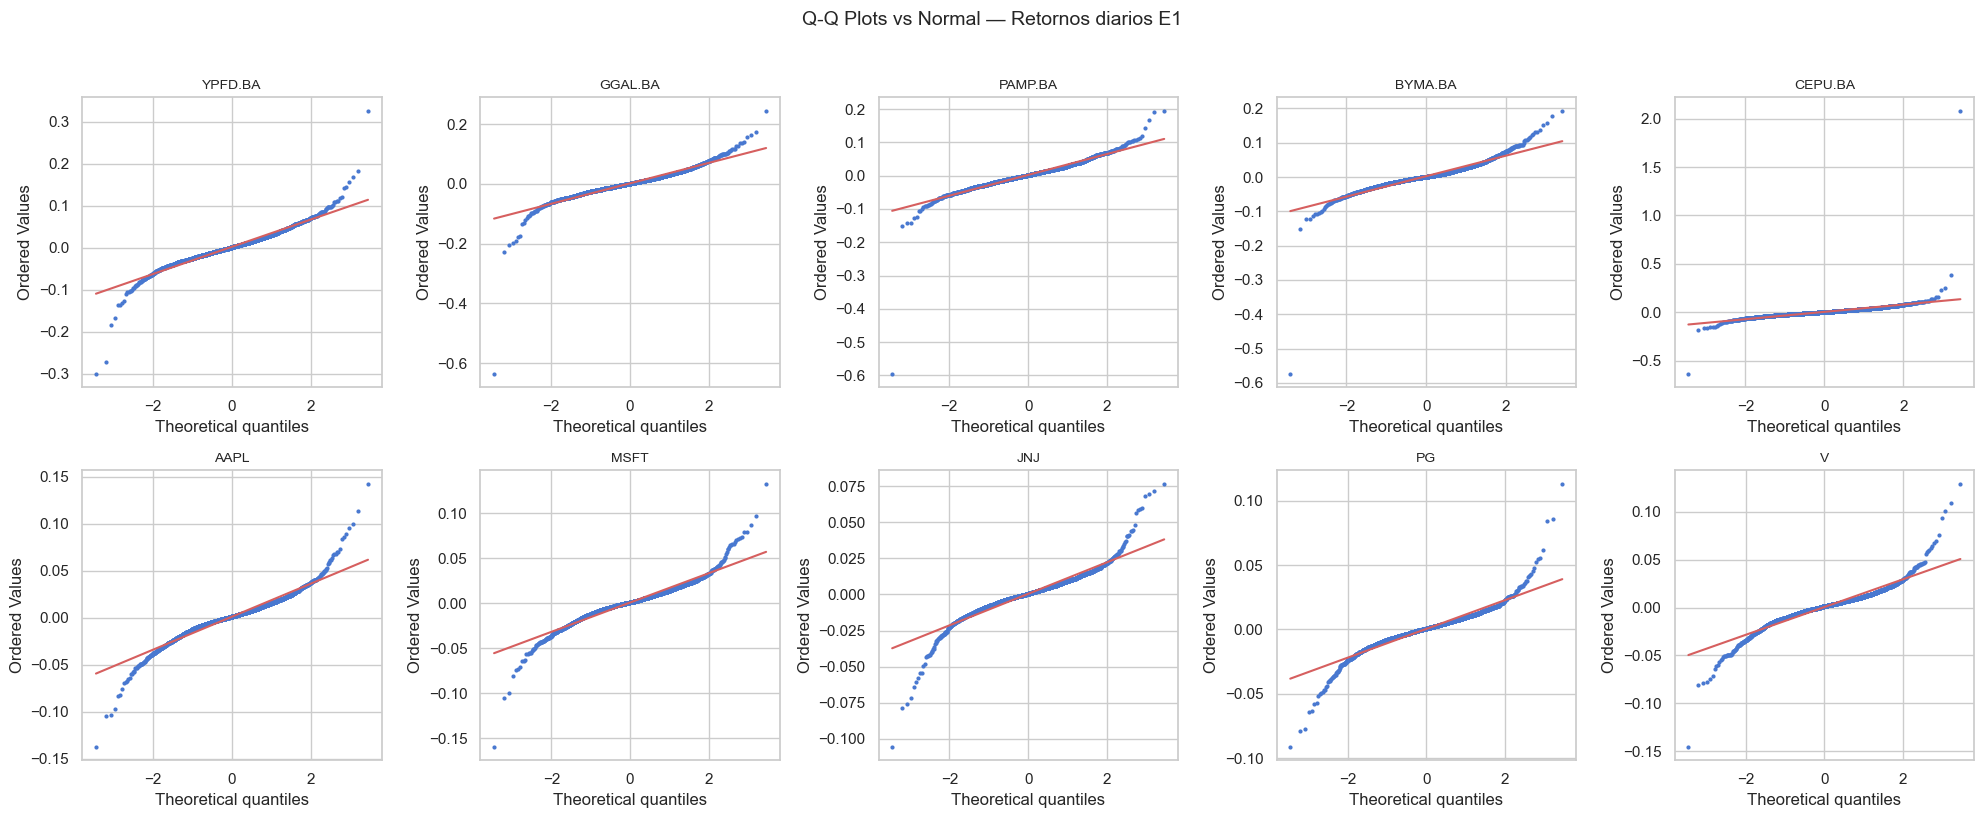

In [29]:
# --- Q-Q plots (quantile-quantile) against the normal distribution ---
# A Q-Q plot compares the quantiles of our data (Y axis) against the theoretical
# quantiles of a normal distribution (X axis). If the data were normal, the points
# would fall on the red diagonal. Departures from the diagonal signal non-normality:
#   - Points above the diagonal in the tails -> fatter tails than the normal
#   - Points below the diagonal in the tails -> lighter tails than the normal

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, ticker in enumerate(E1_TICKERS):
    if ticker not in data:
        continue
    ax = axes[i]
    log_ret = np.log(data[ticker]["close"]).diff().dropna()
    # probplot() computes the quantiles and draws the scatter + reference line
    stats.probplot(log_ret, dist="norm", plot=ax)
    ax.set_title(f"{ticker}", fontsize=10)
    ax.get_lines()[0].set_markersize(2)  # Smaller points for better readability

fig.suptitle("Q-Q plots vs normal — E1 daily returns", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


**Analysis — Daily return distribution**

The histograms and Q-Q plots confirm a classic finding in finance: **returns do NOT follow a normal distribution**.

**Quantitative evidence:**
- **Excess kurtosis** is high on every ticker: AR names range from ku=9.9 (YPFD) to ku=756.6 (CEPU), while US names range from ku=6.8 (AAPL) to ku=11.1 (PG). Values >3 already indicate fat tails; here they are extreme.
- **CEPU.BA is an outlier case** with skewness=20.1 and kurtosis=756.6, which points to extreme positive returns (probably tied to corporate events or restructurings).
- **Negative skewness** on GGAL (-2.14), PAMP (-2.18) and BYMA (-2.17): these tickers have heavier left tails, meaning drops are more severe than rallies. That is typical of emerging markets.
- **Jarque-Bera test**: p=0.0 for every ticker, rejecting normality with full confidence.
 - It is a statistical test combining skewness and kurtosis to answer a single question: "is this data normal?"
 - JB = (n/6) * [skewness^2 + (1/4)(kurtosis - 3)^2]
- The **Q-Q plots** show clear departure in both tails (points drift away from the red diagonal), confirming the fat tails visually.

**Daily volatility** (sigma): AR ~3.3-5.7% vs US ~1.2-1.8%. Argentine tickers are 2-3x more volatile.

**Implication for the model**:
1. Non-normality justifies using **robust loss functions** (Huber) instead of plain MSE, since MSE over-penalizes outliers.
2. High kurtosis justifies using **non-linear models** (GRU) able to capture complex relationships in the tails.
3. CEPU.BA may need special treatment, or at least monitoring of its impact on the model.


### 1.5 Volume distribution (log scale)


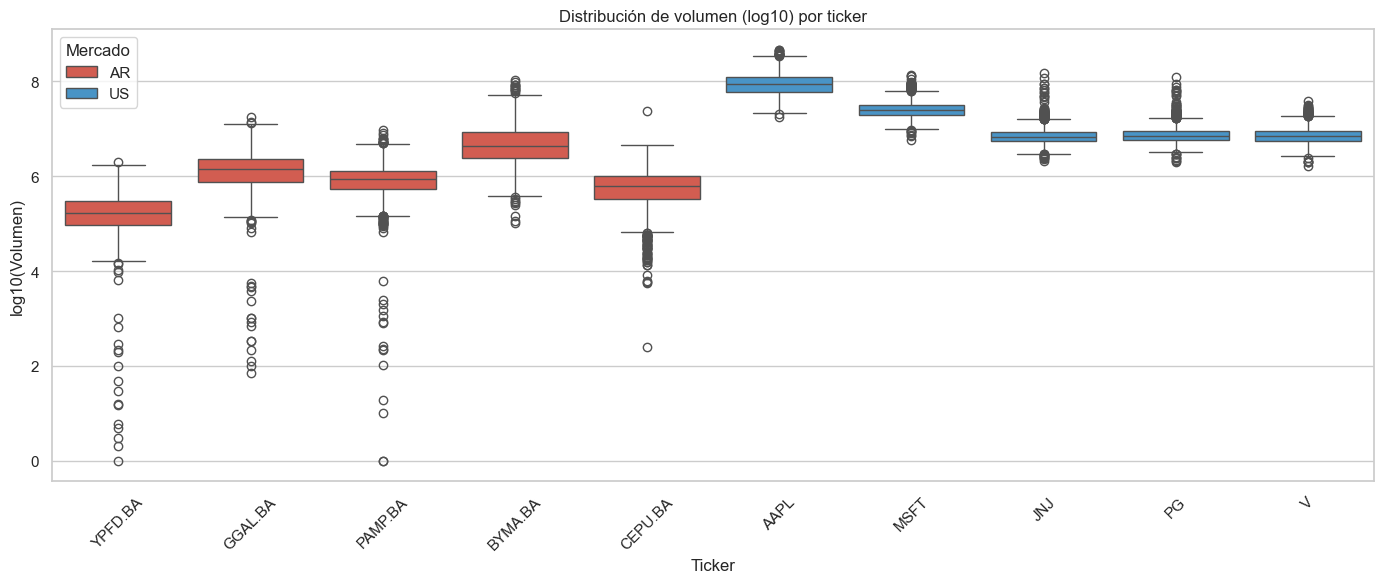

In [30]:
# --- Volume boxplot on a logarithmic scale ---
# Volume (shares traded per day) varies enormously across markets: a US stock can
# trade 100 million shares/day while an AR one trades 100 thousand.
# We use log10 to compress those differences and compare them visually.
# log10(1,000) = 3, log10(1,000,000) = 6, log10(100,000,000) = 8

vol_data = []
for ticker, df in data.items():
    v = df["volume"].copy()
    v = v[v > 0]  # Drop days with volume=0 to avoid log(0) = -infinity
    vol_data.append(pd.DataFrame({
        "log_volume": np.log10(v),  # Convert to base-10 logarithmic scale
        "Ticker": ticker,
        "Market": "AR" if ticker.endswith(".BA") else "US"
    }))

# Concatenate every ticker into a single DataFrame for seaborn
vol_df = pd.concat(vol_data, ignore_index=True)

fig, ax = plt.subplots(figsize=(14, 6))
palette = {"AR": "#E74C3C", "US": "#3498DB"}  # Red for AR, blue for US
# Boxplot: the box spans Q1-Q3 (central 50%), the line is the median,
# whiskers reach 1.5xIQR, and points beyond them are outliers
sns.boxplot(data=vol_df, x="Ticker", y="log_volume", hue="Market",
            palette=palette, ax=ax, dodge=False)
ax.set_title("Volume distribution (log10) by ticker")
ax.set_ylabel("log10(Volume)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Analysis — Trading volume**

The log-scale boxplot reveals structural liquidity differences between markets:

- **US market**: the 5 tickers show medians in the 10^6 - 10^7 range (millions of shares per day), consistent with the high liquidity of NYSE/NASDAQ.
- **AR market**: volumes typically between 10^4 and 10^6, i.e. **2-3 orders of magnitude lower** than the US names. This reflects the shallower depth of the Argentine market.
- **Dispersion** (box length) is larger on AR tickers, indicating greater day-to-day variability in trading activity.

**Note — extremely low volume outliers on YPFD.BA**: while the quality diagnostic (section 1.0) reports 0 days with exactly zero volume, there are **9 days with volume below 100 shares** (absolute minimum: 1 share on 2023-07-13, followed by 2 and 3 shares). Those days most likely correspond to early-close sessions or partial holidays at BYMA. On a log10 scale a volume of 1 shows up as 0.0, which explains the lower outliers visible in the boxplot. These values are not removed from the dataset because `diagnose_data_quality` only filters vol=0, but the `vol_zscore_60` feature naturally captures them as extreme negative anomalies.

**Implication for the model**: the `vol_zscore_60` feature (volume z-score against a 60-day window) normalizes these scale differences, making volume anomalies comparable regardless of the market. That is critical because a "high" volume on BYMA.BA can be 10,000x smaller than a "normal" volume on AAPL.


---
## 2. Feature Analysis


### 2.1 Compute features and target


**Note on warm-up**: ~289 samples per ticker are lost to the technical indicators' warm-up period (the longest is SMA_200, which needs 200 days, plus the 90 days of the forward target). This shrinks the dataset from ~2,500 to ~2,200 samples per US ticker, and from ~2,100-2,400 to ~1,800-2,100 for the AR ones. With 5 walk-forward folds, each fold holds ~400 test samples, which is enough for statistical evaluation.

**Features: 15** `sma_50` and `sma_200` show up as direct features on top of their derivatives (`sma50_sma200_ratio`, `close_sma200_dist`). This is a potential source of multicollinearity, analyzed in the next section.


In [31]:
# --- Compute technical features and target for every ticker ---
# compute_e1_features(df) derives ~15 technical indicators from OHLCV:
#   - Returns (ret_1w, ret_4w, ret_13w), volatility (vol_4w, atr_14),
#   - Trend (sma_50, sma_200, sma50_sma200_ratio), momentum (macd_hist),
#   - Bollinger (bb_pct_b, bb_bandwidth), trend strength (adx_14), etc.
#
# make_target_e1(df, 90) computes the 90-day forward log return:
#   target_ret_90d = ln(price_in_90_days / price_today)
#
# Important: combining features + target drops ~289 rows per ticker:
#   - ~200 rows at the start: SMA_200 "warm-up" (needs 200 days of history)
#   - ~90 rows at the end: no future data left to compute the target

features_all = {}  # {ticker: DataFrame of features}
targets_all = {}   # {ticker: Series with the target}

for ticker, df in data.items():
    feat = compute_e1_features(df)   # DataFrame with ~15 feature columns
    tgt = make_target_e1(df, HORIZON)  # Series with the 90-day return

    # Merge features and target into a single DataFrame and drop rows with NaN
    # (the first ~200 from indicator warm-up, the last ~90 from the forward target)
    combined = pd.concat([feat, tgt], axis=1).dropna()

    features_all[ticker] = combined[feat.columns]  # Feature columns only
    targets_all[ticker] = combined[tgt.name]        # Target column only

    print(f"  {ticker}: {len(combined):,} valid samples (out of {len(df):,} original, "
          f"~{len(df)-len(combined)} dropped to warm-up)")

# Keep the feature names around for the plots that follow
FEATURE_NAMES = list(features_all[E1_TICKERS[0]].columns)
print(f"\nFeatures ({len(FEATURE_NAMES)}): {FEATURE_NAMES}")


  YPFD.BA: 2,142 muestras válidas (de 2,431 originales, warm-up ~289 descartadas)
  GGAL.BA: 2,143 muestras válidas (de 2,432 originales, warm-up ~289 descartadas)
  PAMP.BA: 2,143 muestras válidas (de 2,432 originales, warm-up ~289 descartadas)
  BYMA.BA: 1,824 muestras válidas (de 2,113 originales, warm-up ~289 descartadas)
  CEPU.BA: 2,107 muestras válidas (de 2,396 originales, warm-up ~289 descartadas)
  AAPL: 2,225 muestras válidas (de 2,514 originales, warm-up ~289 descartadas)
  MSFT: 2,225 muestras válidas (de 2,514 originales, warm-up ~289 descartadas)
  JNJ: 2,225 muestras válidas (de 2,514 originales, warm-up ~289 descartadas)
  PG: 2,225 muestras válidas (de 2,514 originales, warm-up ~289 descartadas)
  V: 2,225 muestras válidas (de 2,514 originales, warm-up ~289 descartadas)

Features (15): ['ret_1w', 'ret_4w', 'ret_13w', 'vol_4w', 'vol_regime', 'atr_14', 'vol_zscore_60', 'sma_50', 'sma_200', 'sma50_sma200_ratio', 'close_sma200_dist', 'macd_hist', 'bb_pct_b', 'bb_bandwidth

### 2.2 Feature correlation matrix

**Methodological note**: this section uses `compute_e1_features` from `src.e1.build_features_eda` to show the **first analysis**, with the feature set that predates the multicollinearity cleanup, including `close_sma200_dist`, `vol_4w` and `sma_200`.


MERCADO ARGENTINO — Tickers: ['YPFD.BA', 'GGAL.BA', 'PAMP.BA', 'BYMA.BA', 'CEPU.BA']


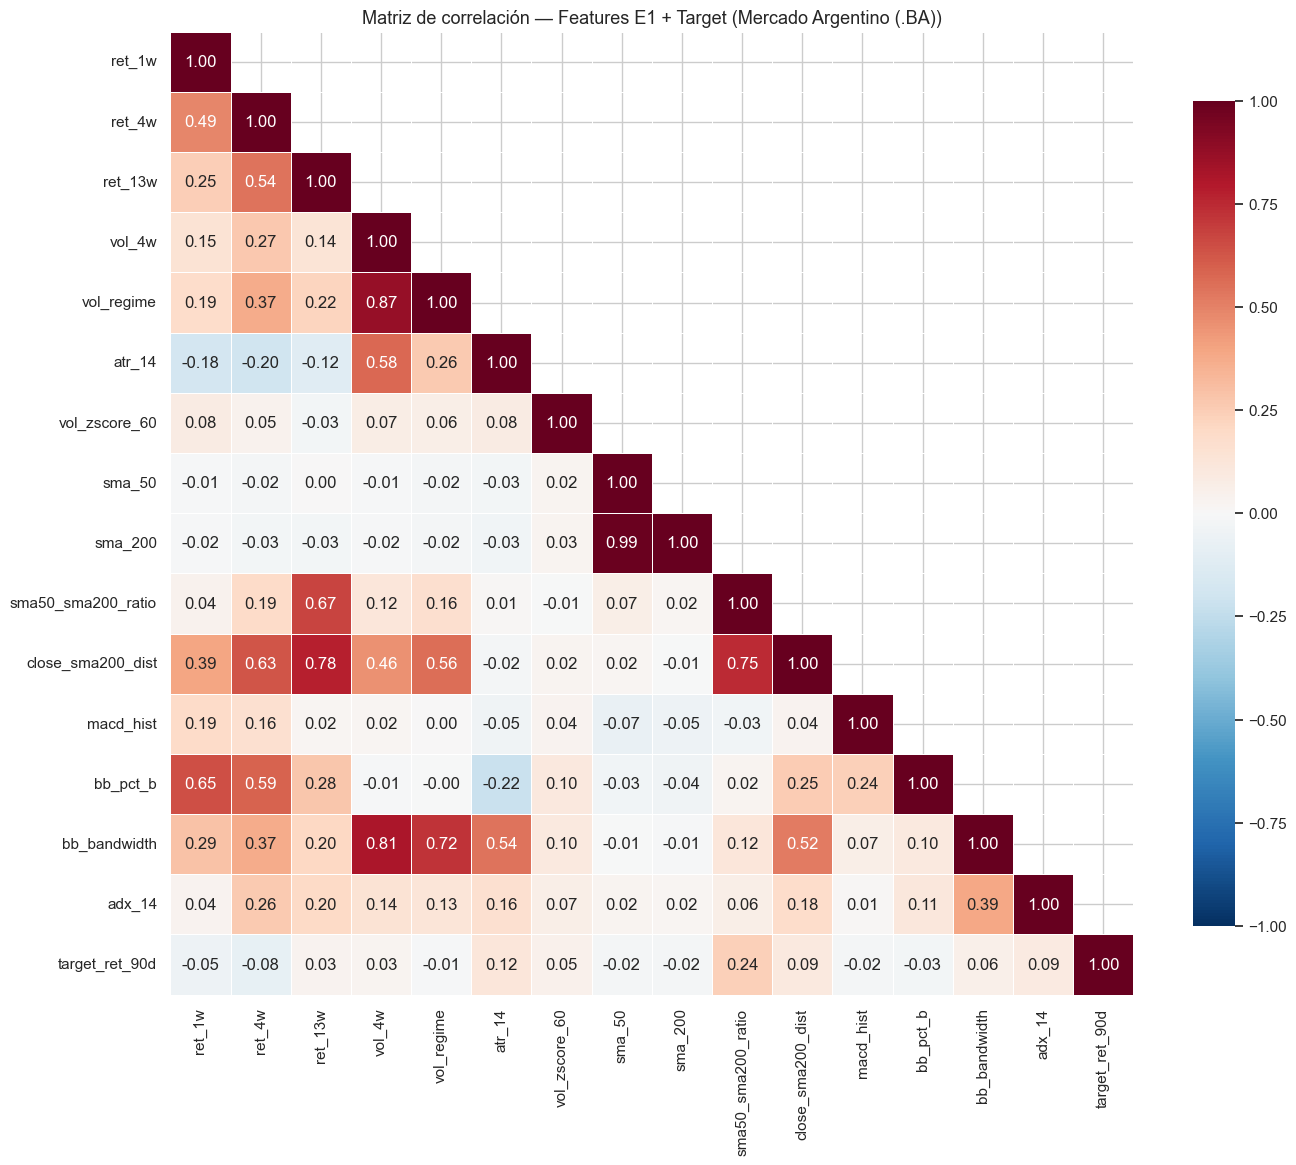


⚠️ Mercado Argentino (.BA) — Pares con correlación |r| > 0.7:
  sma_50 ↔ sma_200: r = 0.986
  vol_4w ↔ vol_regime: r = 0.874
  vol_4w ↔ bb_bandwidth: r = 0.813
  ret_13w ↔ close_sma200_dist: r = 0.775
  sma50_sma200_ratio ↔ close_sma200_dist: r = 0.746
  vol_regime ↔ bb_bandwidth: r = 0.719


MERCADO NORTEAMERICANO — Tickers: ['AAPL', 'MSFT', 'JNJ', 'PG', 'V']


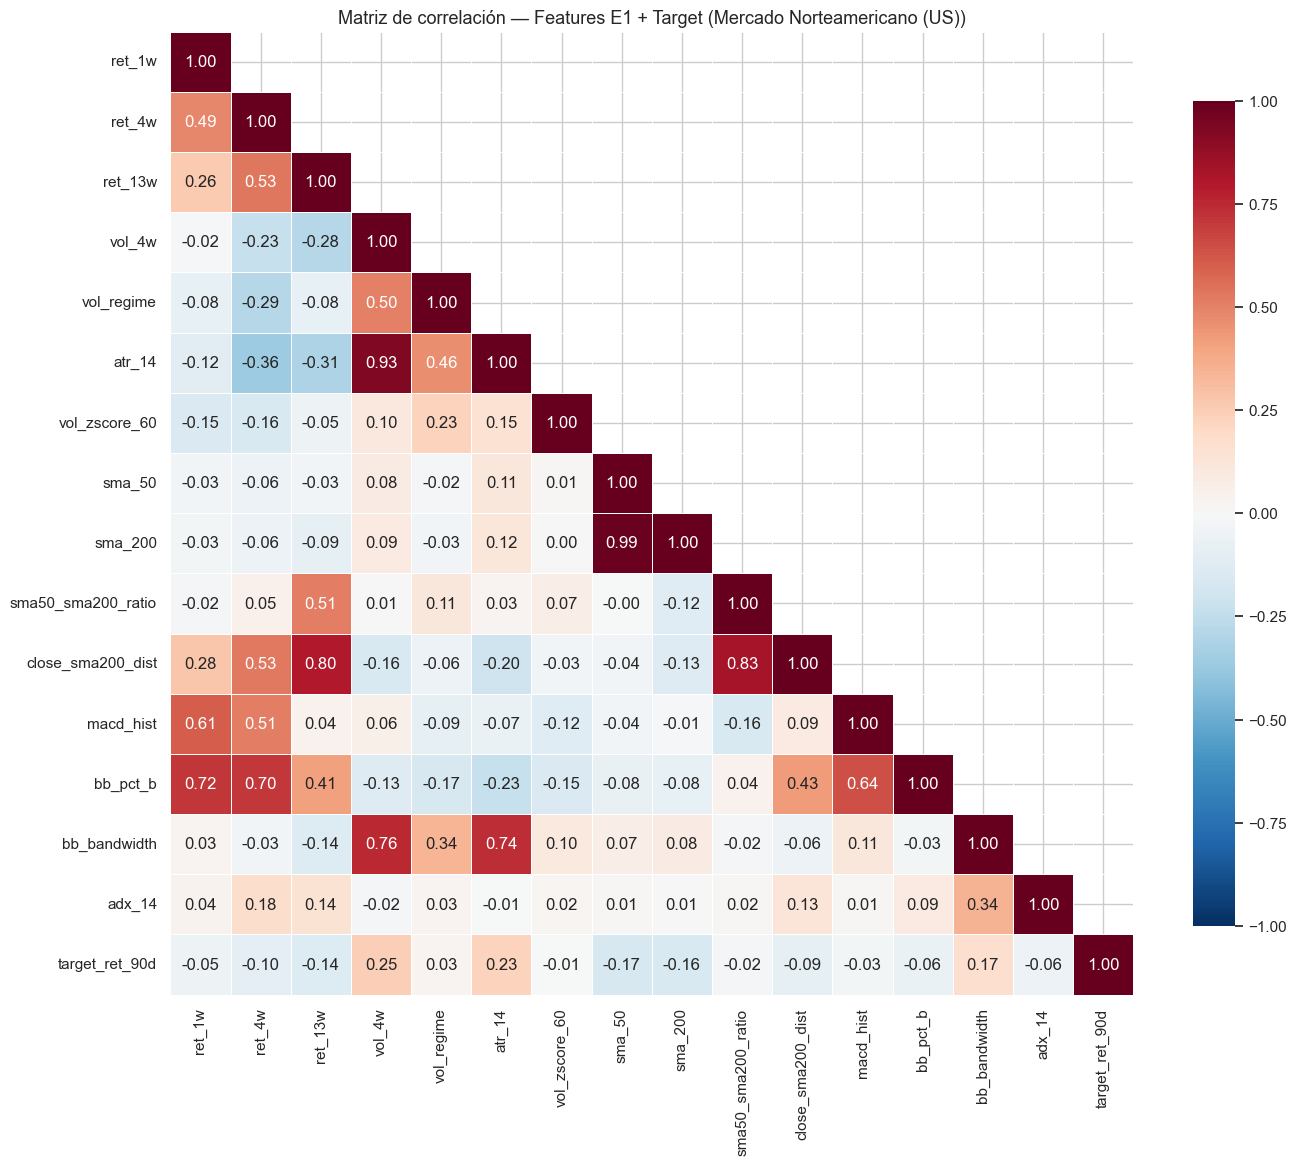


⚠️ Mercado Norteamericano (US) — Pares con correlación |r| > 0.7:
  sma_50 ↔ sma_200: r = 0.991
  vol_4w ↔ atr_14: r = 0.928
  sma50_sma200_ratio ↔ close_sma200_dist: r = 0.83
  ret_13w ↔ close_sma200_dist: r = 0.798
  vol_4w ↔ bb_bandwidth: r = 0.756
  atr_14 ↔ bb_bandwidth: r = 0.737
  ret_1w ↔ bb_pct_b: r = 0.719
  ret_4w ↔ bb_pct_b: r = 0.704


In [32]:
# --- Correlation matrix between features + target — by market ---
# Splitting by market shows whether the feature-target relationships differ
# between Argentina (more volatile, inflation/devaluation effect) and the US (more stable).

def plot_corr_matrix(ticker_list, market_label, color_label):
    """Draw a correlation heatmap and flag pairs with |r| > 0.7."""
    pool = pd.concat([
        pd.concat([features_all[t], targets_all[t]], axis=1)
        for t in ticker_list
    ], ignore_index=True)

    corr = pool.corr()

    fig, ax = plt.subplots(figsize=(14, 12))
    mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
    sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
                center=0, vmin=-1, vmax=1, ax=ax, linewidths=0.5,
                square=True, cbar_kws={"shrink": 0.8})
    ax.set_title(f"Correlation matrix — E1 features + target ({market_label})", fontsize=13)
    plt.tight_layout()
    plt.show()

    # Flag highly correlated pairs
    high_corr = []
    for i in range(len(corr.columns)):
        for j in range(i+1, len(corr.columns)):
            r = corr.iloc[i, j]
            if abs(r) > 0.7:
                high_corr.append((corr.columns[i], corr.columns[j], round(r, 3)))

    if high_corr:
        print(f"\n⚠️ {market_label} — Pairs with correlation |r| > 0.7:")
        for f1, f2, r in sorted(high_corr, key=lambda x: abs(x[2]), reverse=True):
            print(f"  {f1} ↔ {f2}: r = {r}")
    else:
        print(f"\n✓ {market_label} — No pairs with correlation |r| > 0.7")

# --- Argentine market ---
print("=" * 60)
print(f"ARGENTINE MARKET — Tickers: {AR_TICKERS}")
print("=" * 60)
plot_corr_matrix(AR_TICKERS, "Argentine market (.BA)", "AR")

print("\n")

# --- US market ---
print("=" * 60)
print(f"US MARKET — Tickers: {US_TICKERS}")
print("=" * 60)
plot_corr_matrix(US_TICKERS, "US market", "US")


**Analysis — Correlation matrices by market**

Splitting by market exposes structural differences between Argentina and the US:

**Shared multicollinearity** (present in both markets):
- `sma_50` vs `sma_200`: nearly redundant in both markets. The ratio (`sma50_sma200_ratio`) captures the signal better.
- `vol_4w` vs `bb_bandwidth`: both measure volatility from different angles.

**Differences between markets**:
- **Argentina (.BA)**: `vol_regime` vs `vol_4w` are highly correlated, which is expected given that `vol_regime` is computed as the relative change of `vol_4w`. In a more volatile market both metrics tend to move together.
- **US**: the `vol_regime` vs `vol_4w` correlation is markedly lower. In a more stable market, relative volatility changes (`vol_regime`) carry information distinct from the absolute level (`vol_4w`).

**Features dropped for multicollinearity**:

Based on this analysis, 3 features are removed from the E1 feature set:

| Dropped feature | Reason | Replaced by |
|---|---|---|
| `sma_200` | r=0.99 with `sma_50` (absolute prices are nearly identical in scale) | `sma50_sma200_ratio` (captures the relationship between both SMAs as a trend signal) |
| `vol_4w` | r~0.85 with `bb_bandwidth`, r~0.72 with `atr_14` (three overlapping volatility measures) | `bb_bandwidth` and `atr_14` (cover the same information with less redundancy) |
| `close_sma200_dist` | r~0.78 with `sma50_sma200_ratio`, r~0.79 with `ret_13w` | `sma50_sma200_ratio` + `ret_13w` (both already capture the distance-to-long-term signal) |

The internal computation of `sma_200` and `vol_4w` stays in `build_features.py` because `sma50_sma200_ratio` and `vol_regime` depend on them respectively. The final feature set goes from 13 to 10 features.

**Note on `vol_regime`**: even though it correlates with `vol_4w` in the Argentine market, it is kept because (1) in the US market it carries distinct information, and (2) conceptually it measures a *change* of regime (expansion/contraction), not the absolute level of volatility.


### 2.3 Feature vs target (scatter + regression)


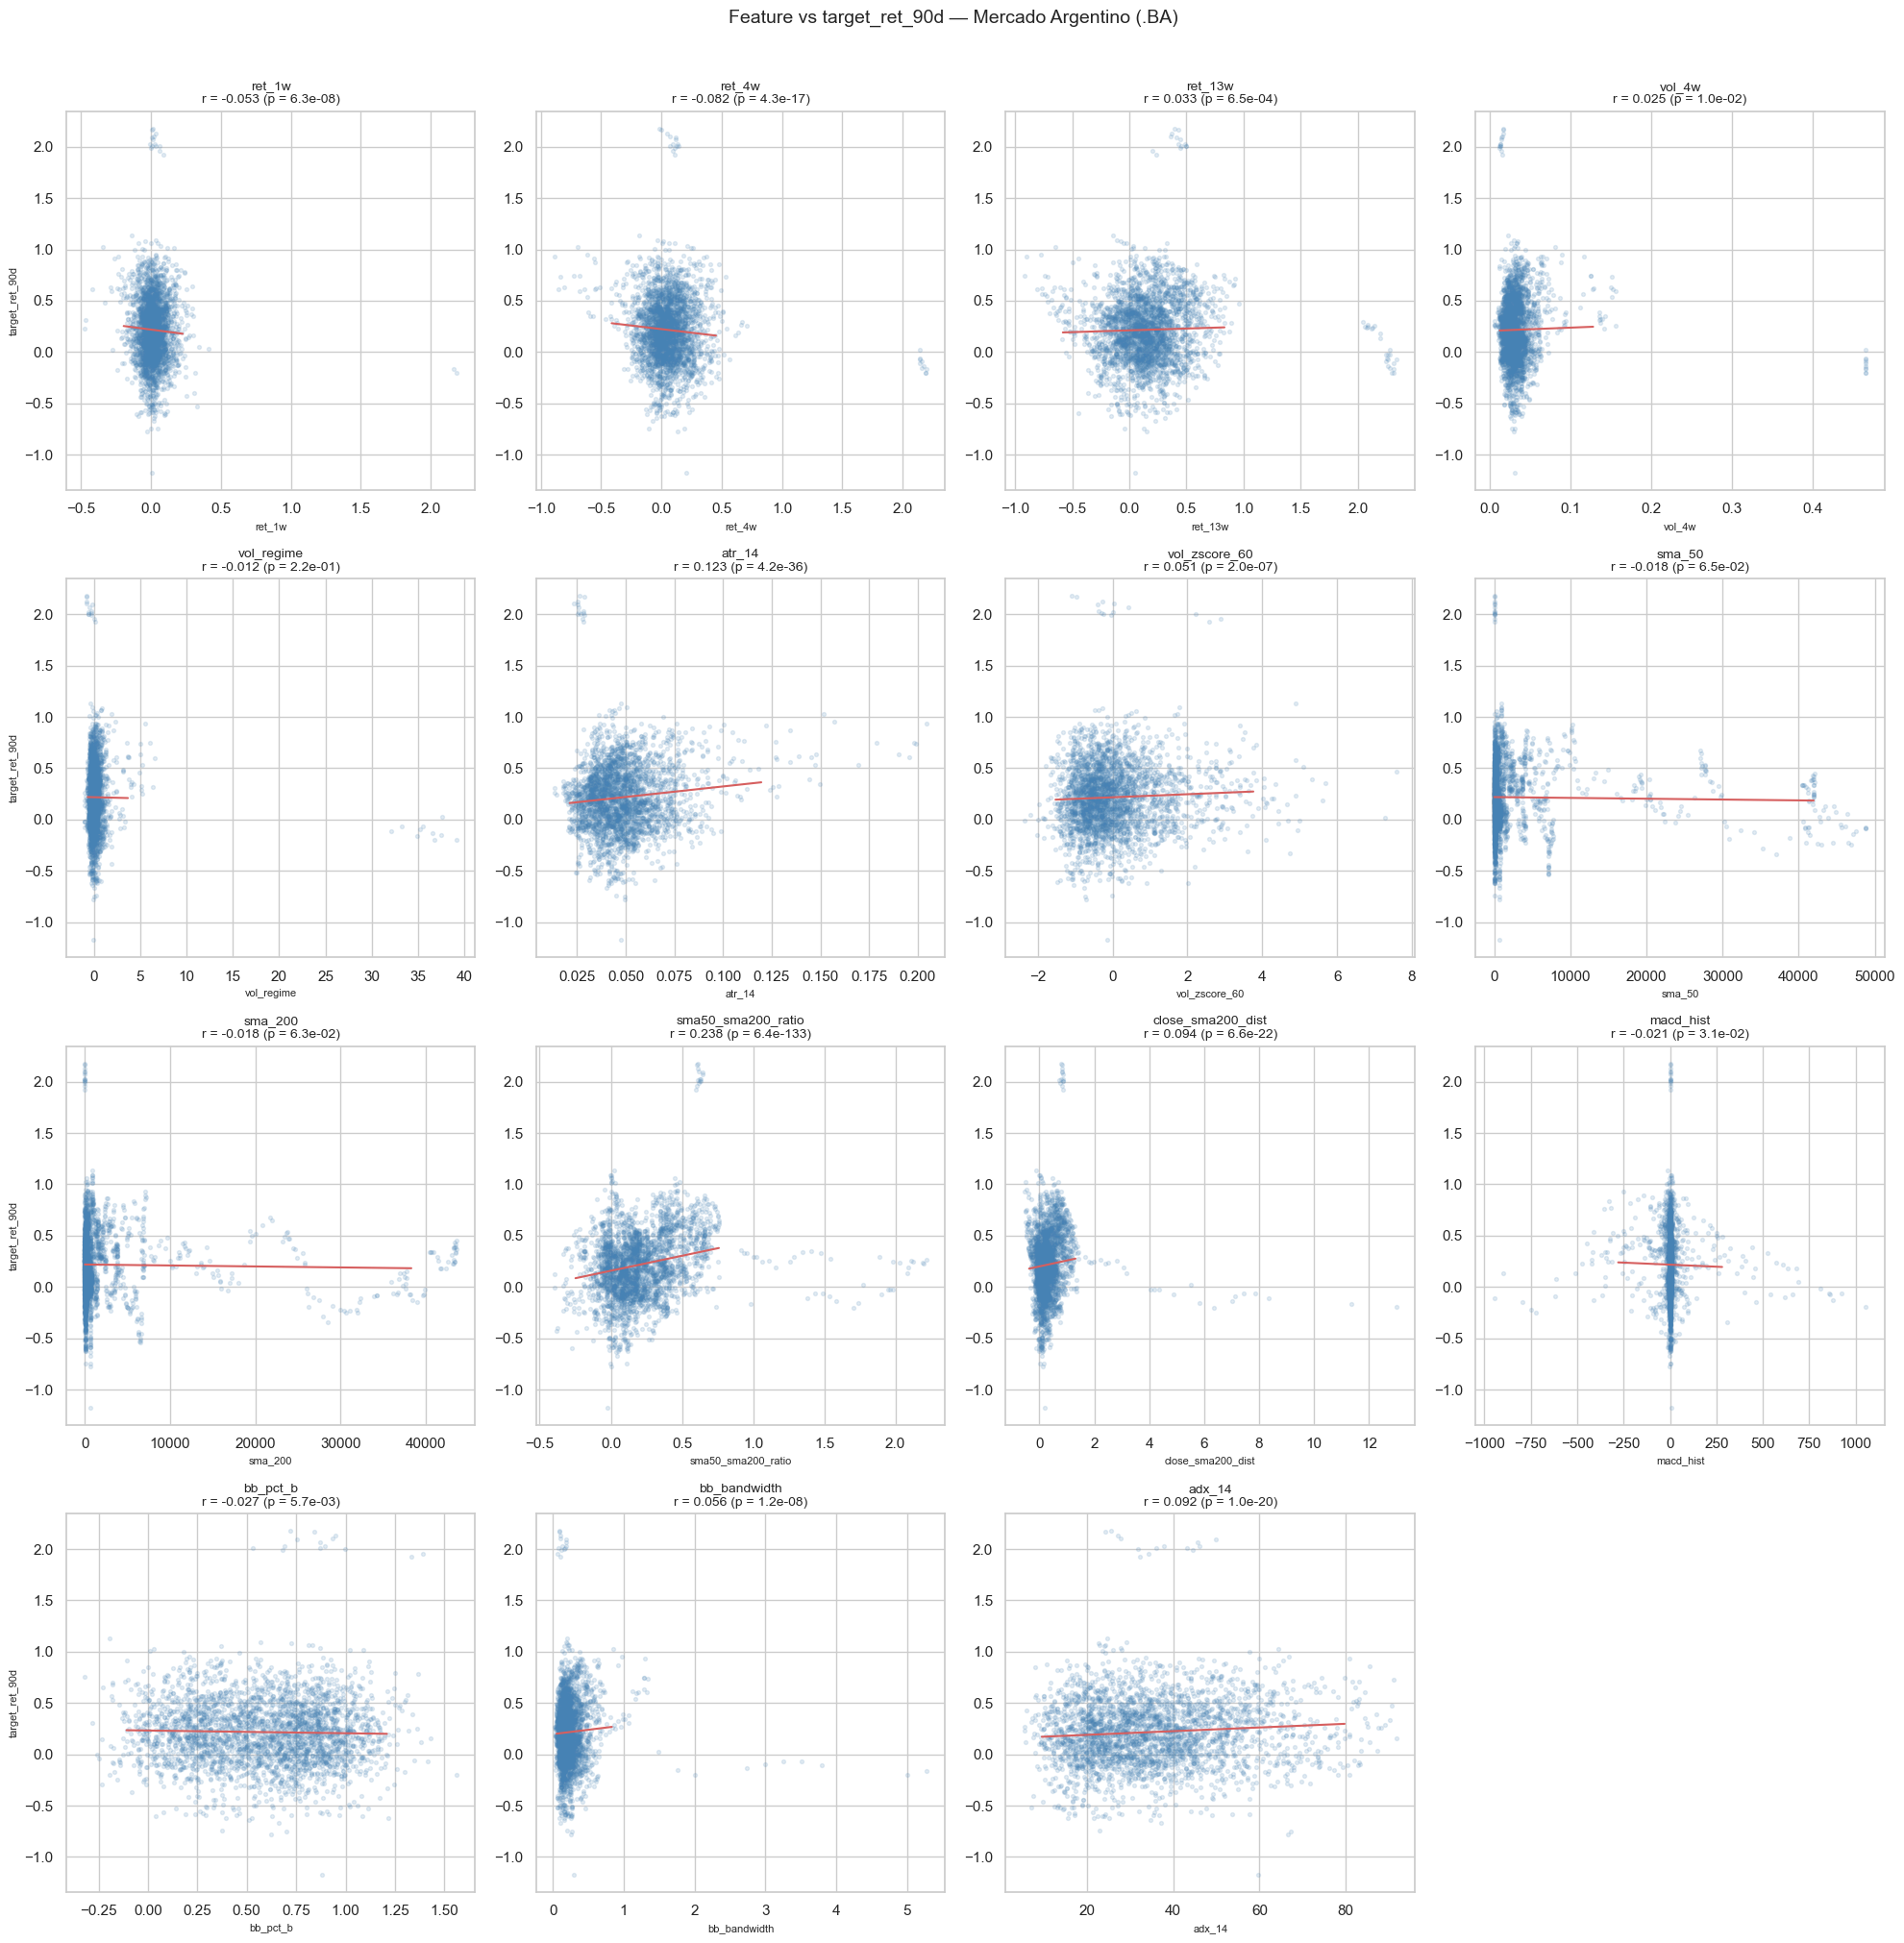

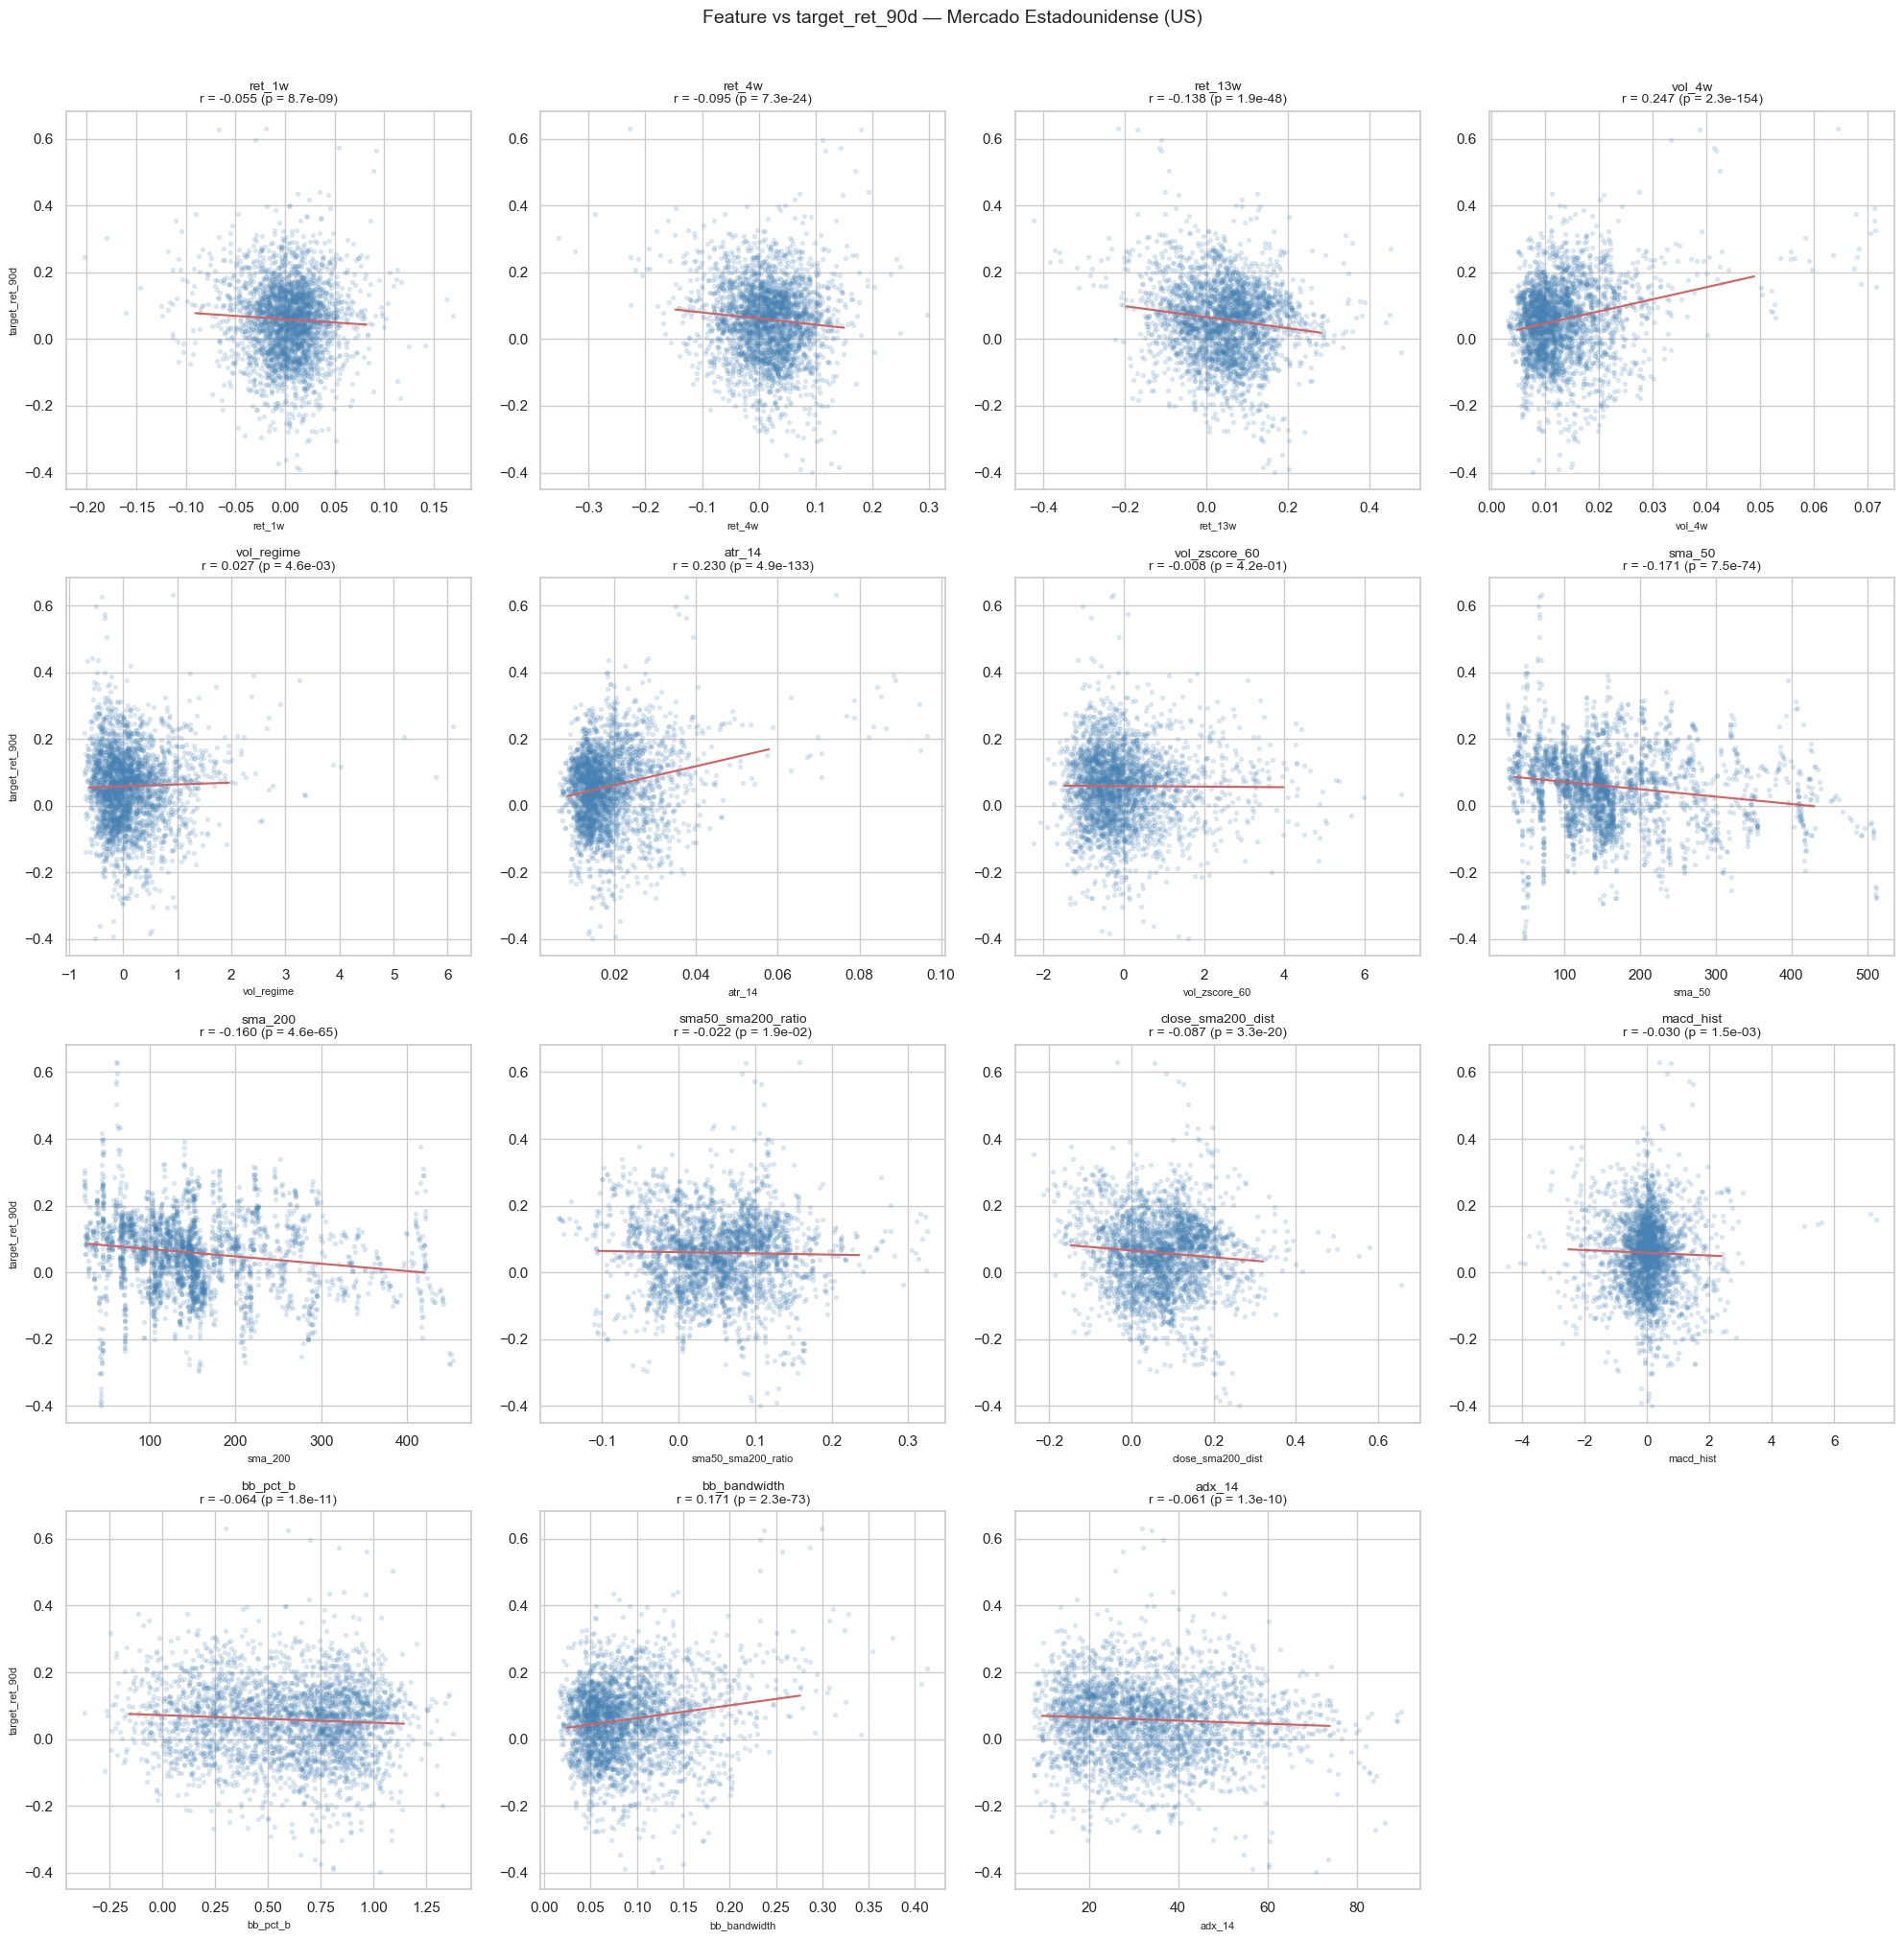

In [33]:
def plot_feature_vs_target(tickers_subset, market_label):
    """Draw scatter plots of every feature against the target for a subset of tickers."""
    # Pooling: concatenate every ticker of the market into a single DataFrame
    pool = pd.concat([
        pd.concat([features_all[t], targets_all[t]], axis=1)
        for t in tickers_subset if t in features_all
    ], ignore_index=True).dropna()

    target_name = f"target_ret_{HORIZON}d"
    ncols = 4
    nrows = (len(FEATURE_NAMES) + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=(20, 5 * nrows))
    fig.suptitle(f"Feature vs {target_name} — {market_label}", fontsize=14, y=1.01)
    axes = axes.flatten()

    for i, feat_name in enumerate(FEATURE_NAMES):
        ax = axes[i]
        x = pool[feat_name]
        y = pool[target_name]

        # Subsampling: with more than 3000 points, draw a random sample
        if len(x) > 3000:
            idx = np.random.RandomState(42).choice(len(x), 3000, replace=False)
            x_plot, y_plot = x.iloc[idx], y.iloc[idx]
        else:
            x_plot, y_plot = x, y

        # Scatter plot: each point is one day of one ticker
        ax.scatter(x_plot, y_plot, alpha=0.15, s=8, color="steelblue")

        # Linear regression line fitted on ALL the data (not just the subsample)
        m, b = np.polyfit(x.values, y.values, 1)
        x_line = np.linspace(x.quantile(0.01), x.quantile(0.99), 100)
        ax.plot(x_line, m * x_line + b, "r-", linewidth=1.5)

        # Pearson correlation (r) and its p-value
        r, p = stats.pearsonr(x, y)
        ax.set_title(f"{feat_name}\nr = {r:.3f} (p = {p:.1e})", fontsize=10)
        ax.set_xlabel(feat_name, fontsize=8)
        if i % ncols == 0:
            ax.set_ylabel(target_name, fontsize=8)

    for j in range(len(FEATURE_NAMES), len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

plot_feature_vs_target(AR_TICKERS, "Argentine market (.BA)")
plot_feature_vs_target(US_TICKERS, "US market")


**Analysis — Feature vs target by market**

Splitting the analysis by market reveals that the correlations in the pooled analysis were biased by the inflationary effect of the Argentine tickers:

**Argentine market (.BA)**
- The highest correlations concentrate in volatility features (`atr_14`, `vol_4w`, `bb_bandwidth`): on AR tickers nominal volatility rises together with nominal returns because of devaluation, producing a spurious correlation between volatility and the 90d return.
- `sma50_sma200_ratio` keeps a positive correlation: it reflects that during uptrend cycles (ARS vs USD) returns are higher.
- Most significant correlations in AR are **inflated by the peso price scale**, not by genuine trading signals.

**US market**
- Lower correlations overall (a more efficient market).
- The significant r values are **more trustworthy as real signal** than the AR ones, since there is no inflationary bias.
- Momentum features (`rsi_14`, `macd_hist`) may show more relative predictive power in the US than in AR.
- `vol_regime` still shows no significant linear relationship in either market.

**Implication for the GRU model**:
- It confirms that **per-ticker** Z-score normalization (not pooled) is critical to keep the model from reading high nominal AR volatility as genuine predictive signal.
- The GRU has to capture non-linear interactions and temporal patterns, since no single feature explains more than ~10% of the target variance in either market.


---
## 3. Target Analysis


### 3.1 Target distribution by ticker


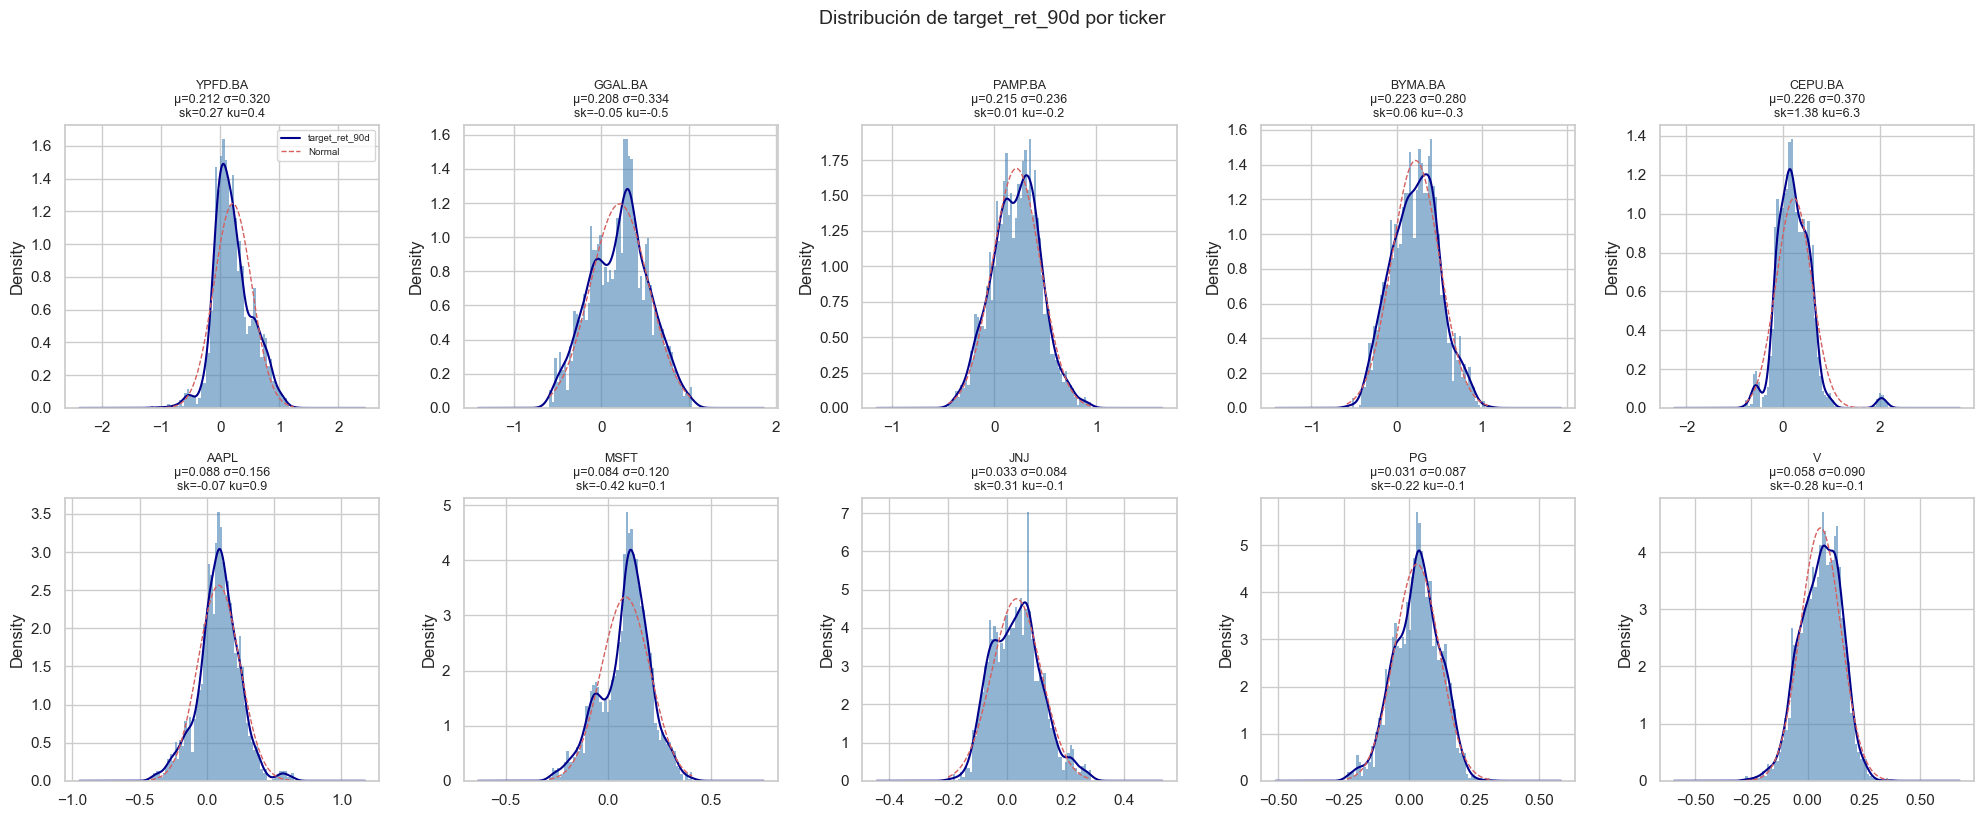

In [34]:
# --- Target distribution (90-day return) by ticker ---
# Same structure as the daily return histograms (histogram + KDE + normal fit),
# but now for the target: log return accumulated over the next 90 days.
# Example: target = 0.2 means the price rose ~22% over the next 90 days
#          (e^0.2 ~ 1.22, i.e. +22%)

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

target_name = f"target_ret_{HORIZON}d"

for i, ticker in enumerate(E1_TICKERS):
    if ticker not in targets_all:
        continue
    ax = axes[i]
    tgt = targets_all[ticker]

    # Target histogram
    ax.hist(tgt, bins=60, density=True, alpha=0.6, color="steelblue", edgecolor="none")
    # Smoothed KDE
    tgt.plot.kde(ax=ax, color="darkblue", linewidth=1.5)

    # Theoretical normal curve for comparison
    mu, sigma = tgt.mean(), tgt.std()
    x = np.linspace(tgt.min(), tgt.max(), 200)
    ax.plot(x, stats.norm.pdf(x, mu, sigma), "r--", linewidth=1, label="Normal")

    # Statistics in the title:
    # mu: mean 90-day return. E.g. 0.21 = +21% on average
    # sigma: dispersion. The larger it is, the harder to predict
    sk = stats.skew(tgt)
    ku = stats.kurtosis(tgt)
    ax.set_title(f"{ticker}\nμ={mu:.3f} σ={sigma:.3f}\nsk={sk:.2f} ku={ku:.1f}", fontsize=9)
    if i == 0:
        ax.legend(fontsize=7)

fig.suptitle(f"Distribution of {target_name} by ticker", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


**Analysis — Target distribution (90-day return)**

The target looks very different across markets:

**Argentine market** (mean 90d return: ~21%):
- High mean: YPFD (21.3%), GGAL (20.8%), PAMP (21.7%), BYMA (22.3%), CEPU (23.0%). These values reflect **Argentine inflation** baked into nominal prices.
- High standard deviation: between 0.24 (PAMP) and 0.38 (CEPU), indicating high uncertainty at 90 days.
- CEPU.BA is again atypical: ku=6.7 and max=2.19 (a +219% return over 90 days), confirming extreme events.

**US market** (mean 90d return: ~3-9%):
- Moderate mean: AAPL (8.9%), MSFT (8.5%), V (5.8%), JNJ (3.3%), PG (3.1%). Consistent with long-term real returns of the S&P 500.
- Lower standard deviation: between 0.08 (JNJ, PG) and 0.16 (AAPL).
- Low kurtosis (~0 to 0.9): distributions closer to normal than the daily returns.

**Implication for the model**: the huge scale difference in the target (mu=21% AR vs mu=5% US) reinforces the need for per-ticker Z-score normalization during training.


### 3.2 Target over time


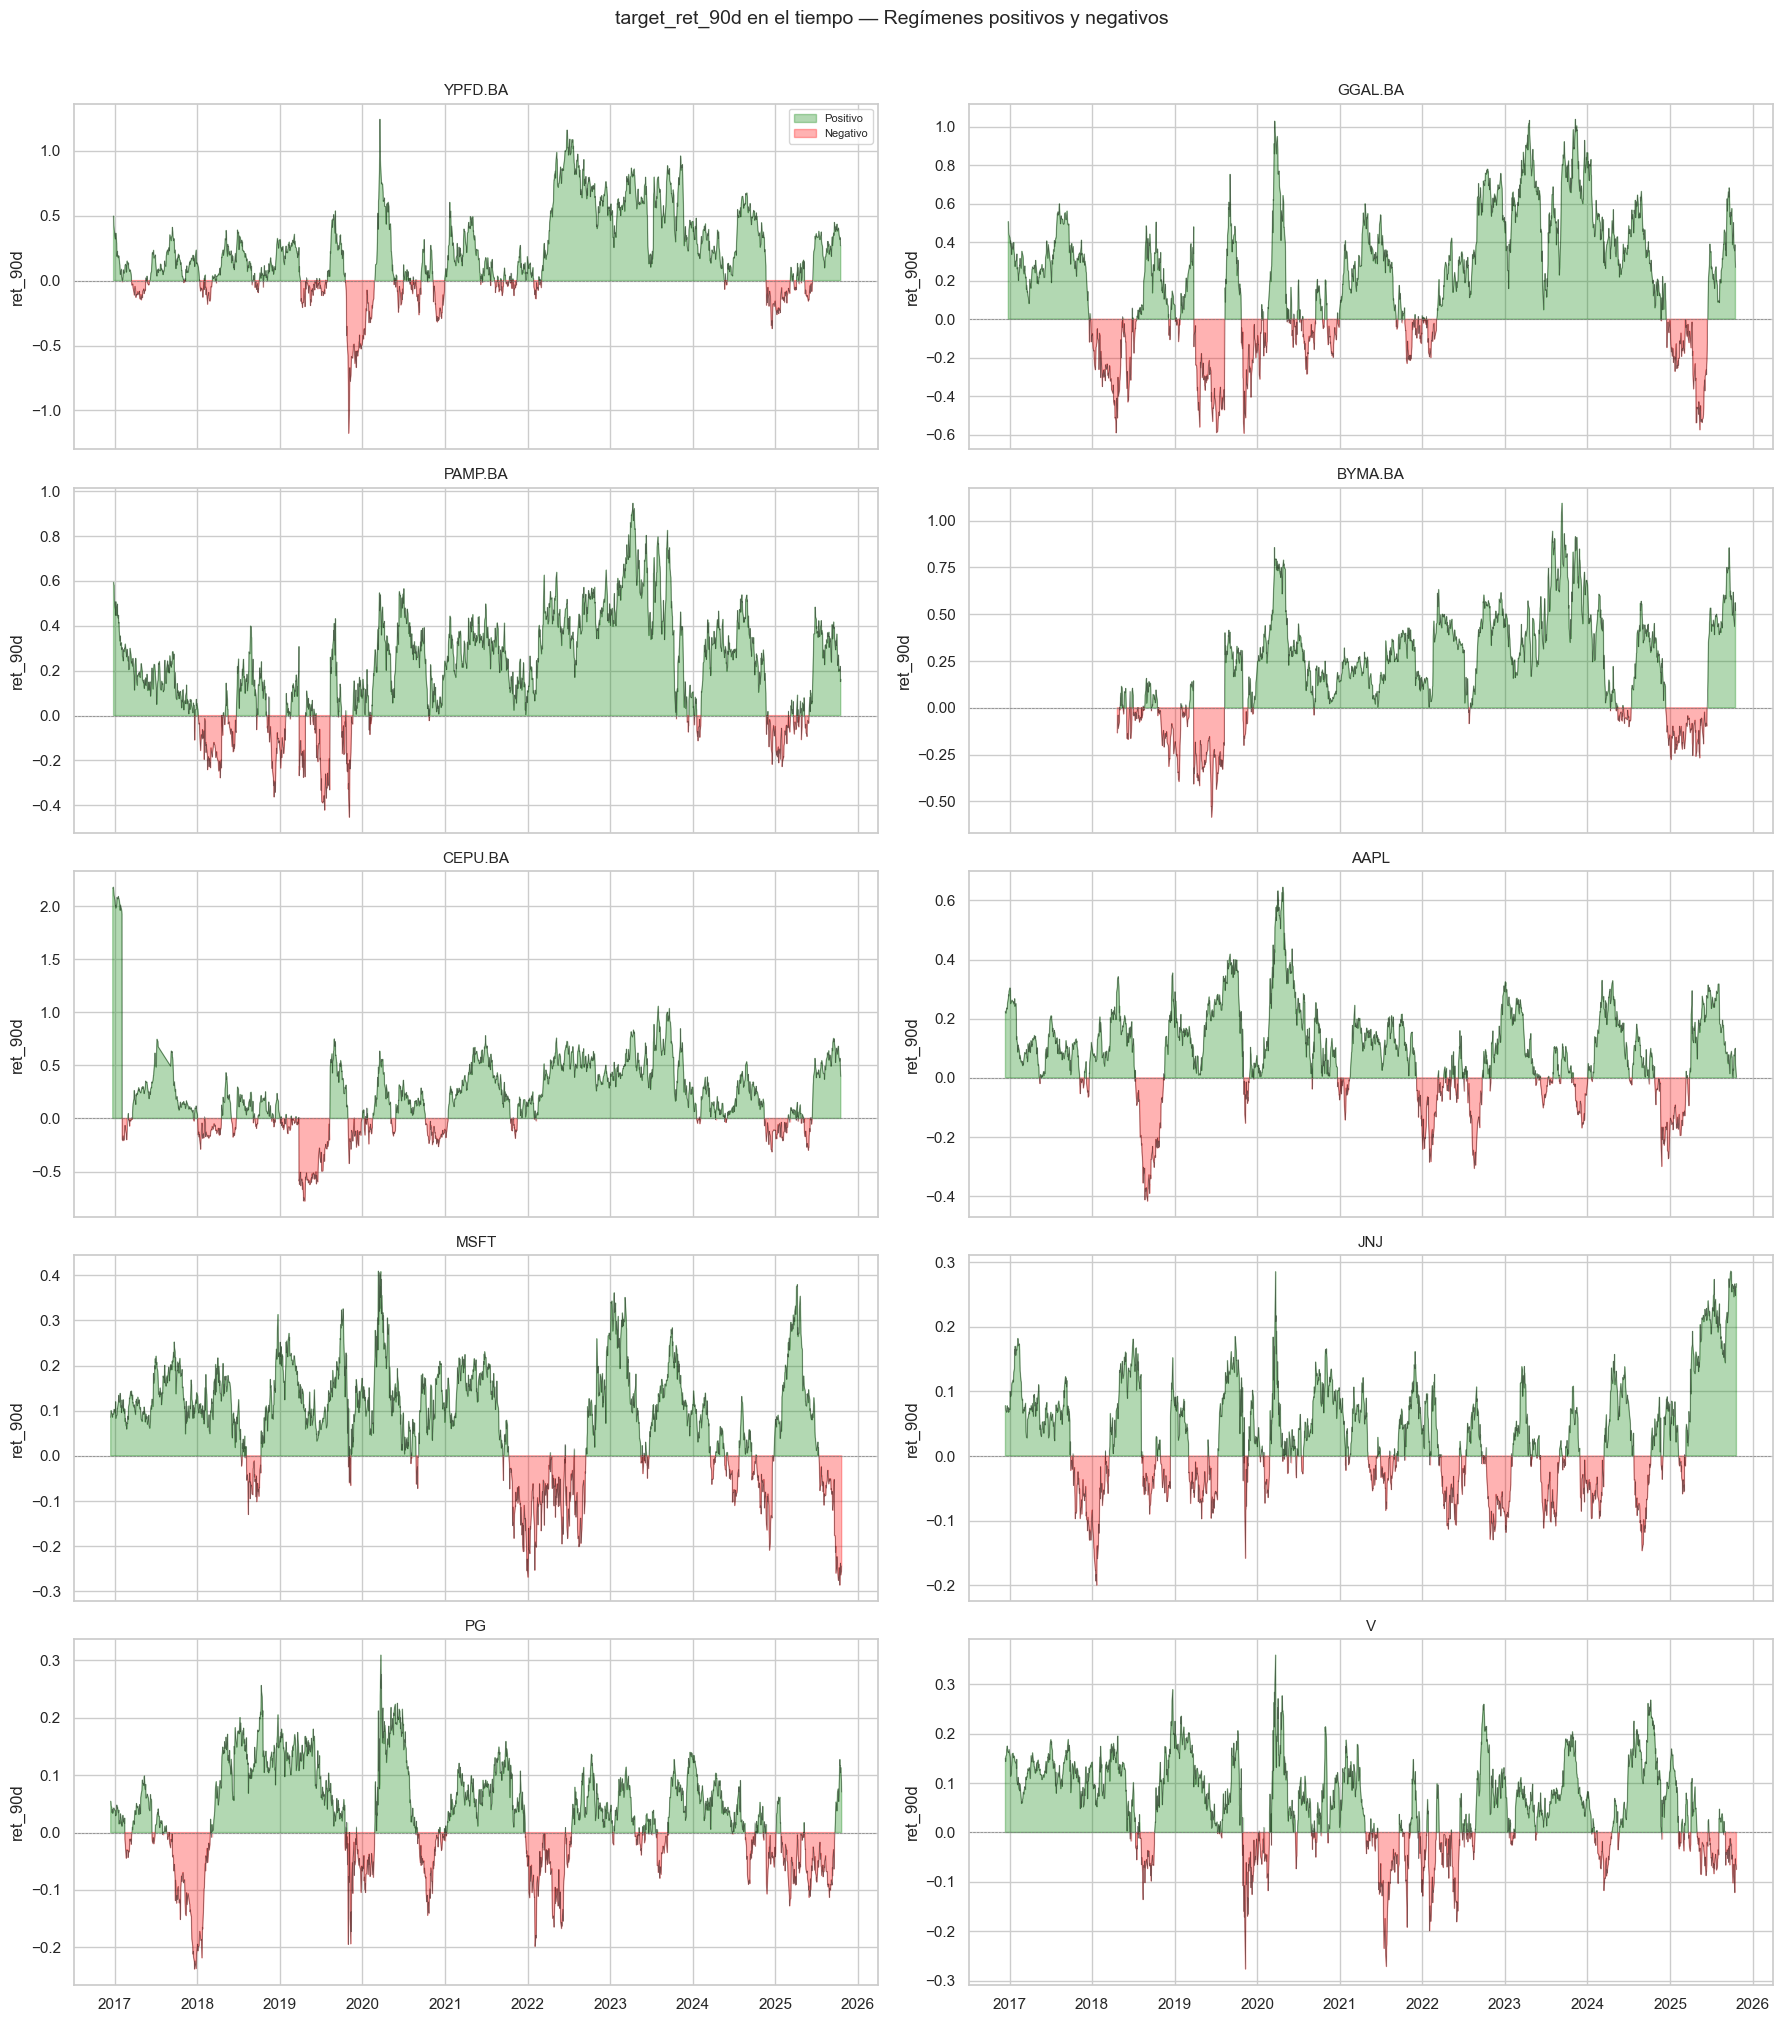

In [35]:
# --- Target over time: positive and negative regimes ---
# For each ticker we plot target_ret_90d as a time series.
# Green = periods where the 90d return was positive (bull market)
# Red = periods where the 90d return was negative (bear market)
# This makes market "regimes" visible at a glance.

fig, axes = plt.subplots(5, 2, figsize=(18, 20), sharex=True)  # sharex: shared X axis (time)
axes = axes.flatten()

for i, ticker in enumerate(E1_TICKERS):
    if ticker not in targets_all:
        continue
    ax = axes[i]
    tgt = targets_all[ticker]

    # fill_between: shades the area between the line and the Y=0 axis
    # where=tgt >= 0: only shade where the target is positive (green)
    ax.fill_between(tgt.index, tgt.values, 0,
                    where=tgt.values >= 0, color="green", alpha=0.3, label="Positive")
    # where=tgt < 0: only shade where the target is negative (red)
    ax.fill_between(tgt.index, tgt.values, 0,
                    where=tgt.values < 0, color="red", alpha=0.3, label="Negative")
    # Thin black line to see the exact contour
    ax.plot(tgt.index, tgt.values, color="black", linewidth=0.5, alpha=0.5)
    ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")  # Horizontal line at Y=0
    ax.set_title(f"{ticker}", fontsize=11)
    ax.set_ylabel(f"ret_{HORIZON}d")
    if i == 0:
        ax.legend(fontsize=8)

fig.suptitle(f"{target_name} over time — positive and negative regimes", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


**Analysis — Target over time**

The target time series reveals **clear market regimes**:

- **Prolonged positive periods (green)**: there are months-long stretches where the 90-day return is consistently positive, indicating sustained uptrends. This is especially marked on AR tickers, where inflation creates a structural bullish bias.
- **Synchronized drops**: negative periods (red) tend to happen simultaneously across tickers of the same market (COVID-2020 is visible on all of them). That points to **systemic risk**: when the market falls, it falls for everyone.
- **AR vs US tickers**: AR names swing wider (broader green/red bands) with sharper transitions between regimes. US names show longer, less extreme regimes.
- **Temporal asymmetry**: negative periods tend to be shorter but more intense than positive ones (fast drops, slow recoveries), especially on US tickers.

**Implication for the model**: the clear presence of regimes justifies **walk-forward validation** instead of a static time split, since a fixed split could train on one regime and test on a completely different one.


### 3.3 Target autocorrelation (ACF / PACF)


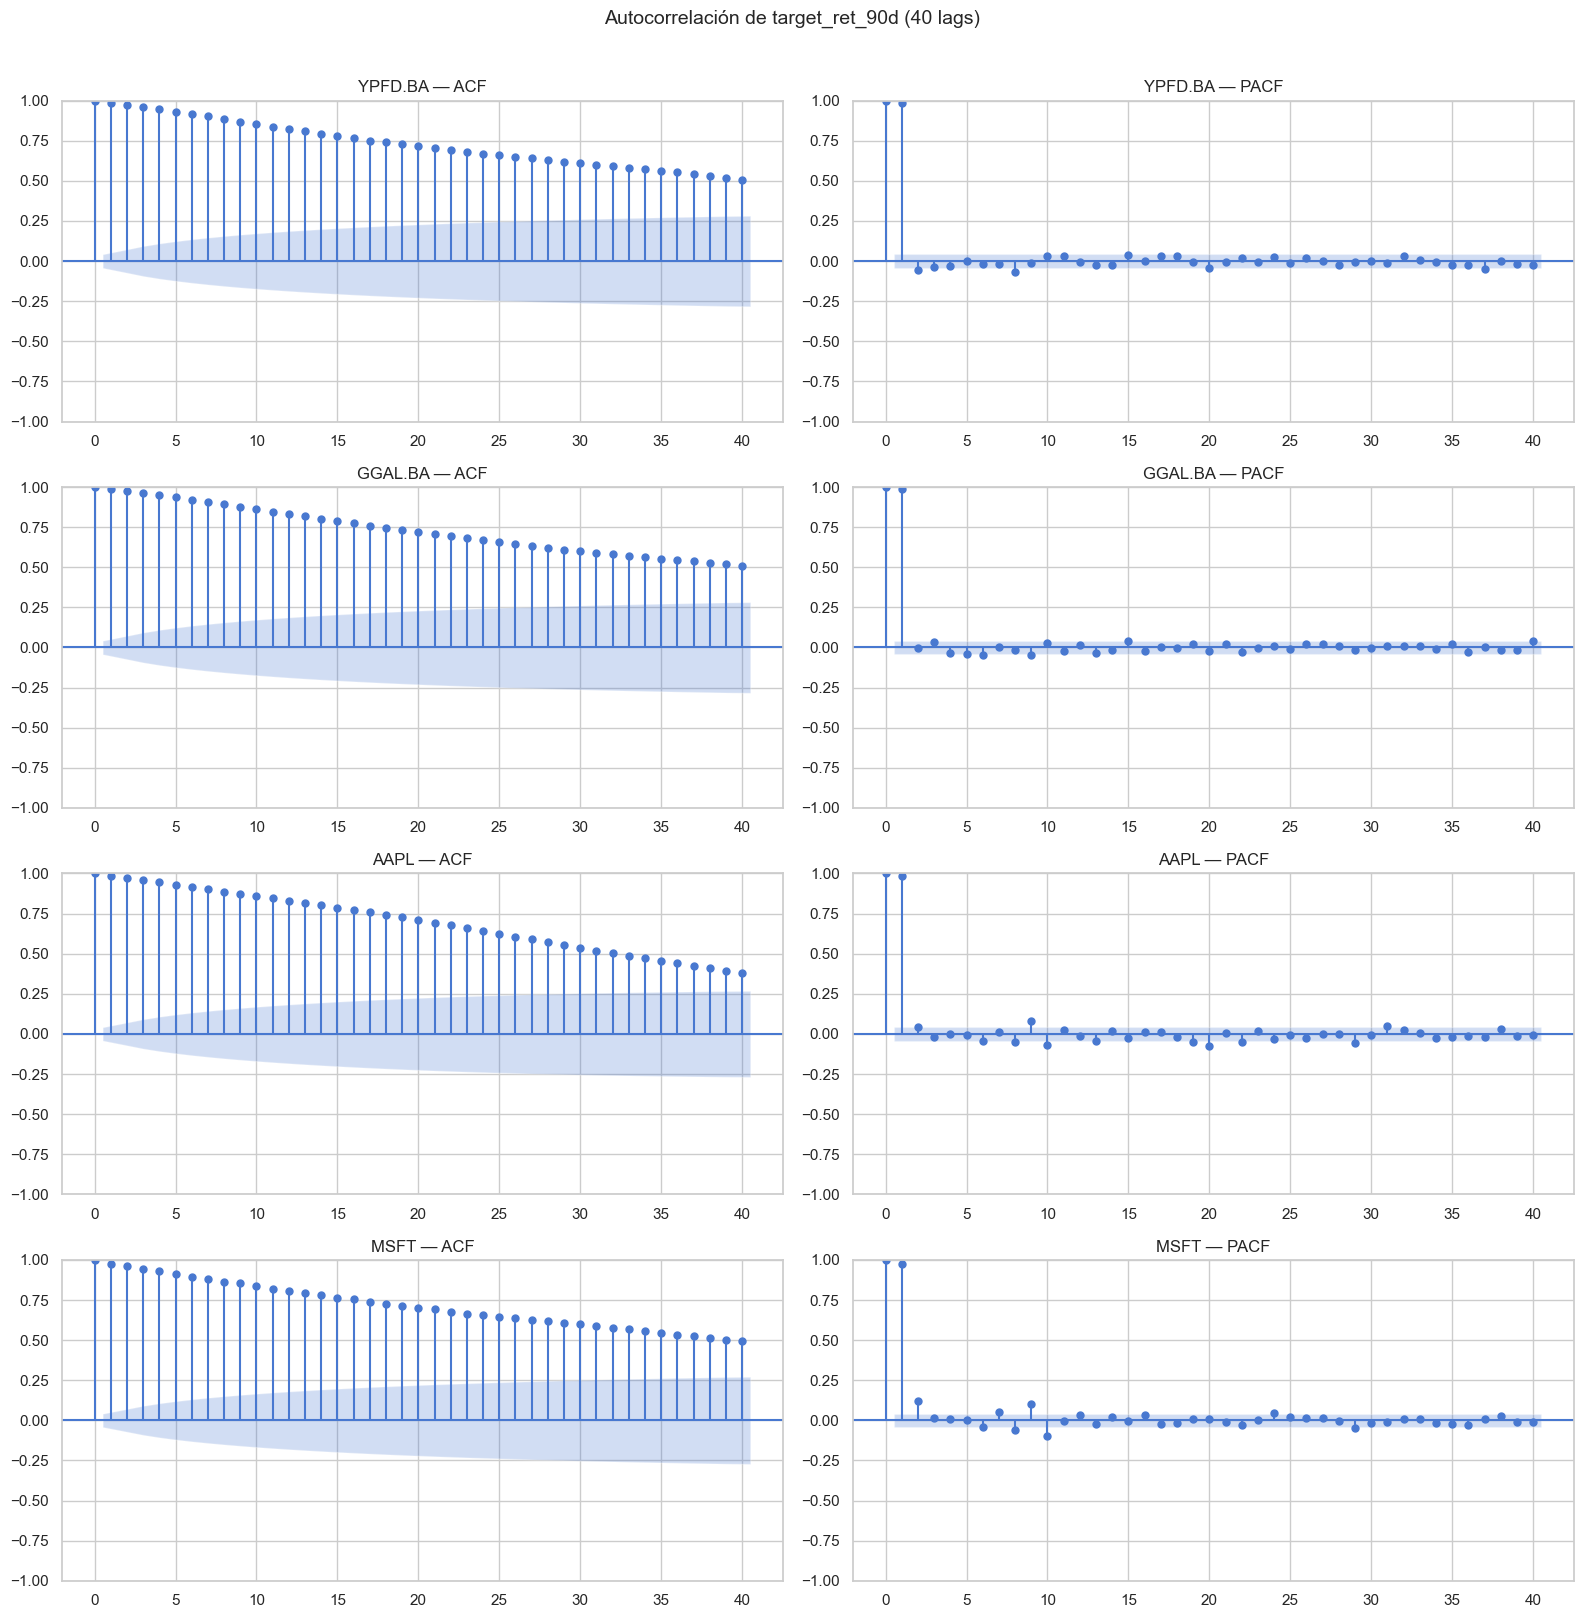

In [36]:
# --- ACF / PACF of the target ---
# ACF (Autocorrelation Function): measures the correlation of the target with
# itself shifted in time (lags). If ACF(lag=5) = 0.9, today's target and the one
# from 5 days ago are 90% correlated.
#
# PACF (Partial ACF): similar but "controlling" for the intermediate lags.
# If PACF(lag=5) is high while PACF(lag=2,3,4) are low, the correlation at lag 5
# is not explained purely by transmission through lags 1->2->3->4->5.
#
# We show 4 representative tickers (2 AR + 2 US) to keep the figure readable.

sample_tickers = [AR_TICKERS[0], AR_TICKERS[1], US_TICKERS[0], US_TICKERS[1]]
sample_tickers = [t for t in sample_tickers if t in targets_all]

fig, axes = plt.subplots(len(sample_tickers), 2, figsize=(16, 4 * len(sample_tickers)))

for i, ticker in enumerate(sample_tickers):
    tgt = targets_all[ticker].dropna()

    # lags=40: look at the correlation up to a 40-day shift
    # The shaded blue band is the 95% confidence interval:
    # bars outside the band = statistically significant correlation
    plot_acf(tgt, ax=axes[i, 0], lags=40, title=f"{ticker} — ACF")
    plot_pacf(tgt, ax=axes[i, 1], lags=40, title=f"{ticker} — PACF", method="ywm")

fig.suptitle(f"Autocorrelation of {target_name} (40 lags)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


**Analysis — Target autocorrelation**

The ACF and PACF plots show **extremely high autocorrelation** in the target, with coefficients that decay slowly:

- **ACF**: the coefficients stay significant (outside the blue confidence band) up to lag 40 and beyond. The decay is gradual, with no abrupt cut-off.
- **PACF**: shows a dominant spike at lag 1 and decays fast. That indicates the autocorrelation is transmitted mainly through consecutive observations.

**Cause**: this autocorrelation is **mechanical, not informative**. The `target_ret_90d` target is computed as the cumulative return over a 90-day window that slides one day at a time. Two consecutive observations (day t and day t+1) share 89 of their 90 days, so they are almost identically correlated.

**Consequence**: without a proper **embargo** in the temporal validation, the model could "see" test-set information through this mechanical correlation. The 90-day embargo configured in `base.yaml` removes exactly this dependency, since it guarantees no test observation shares days with the train set.

**This is NOT model leakage**, but an intrinsic property of targets built on overlapping windows. The current pipeline configuration (embargo >= horizon) handles it correctly.


### 3.4 Rolling mean and std of the target


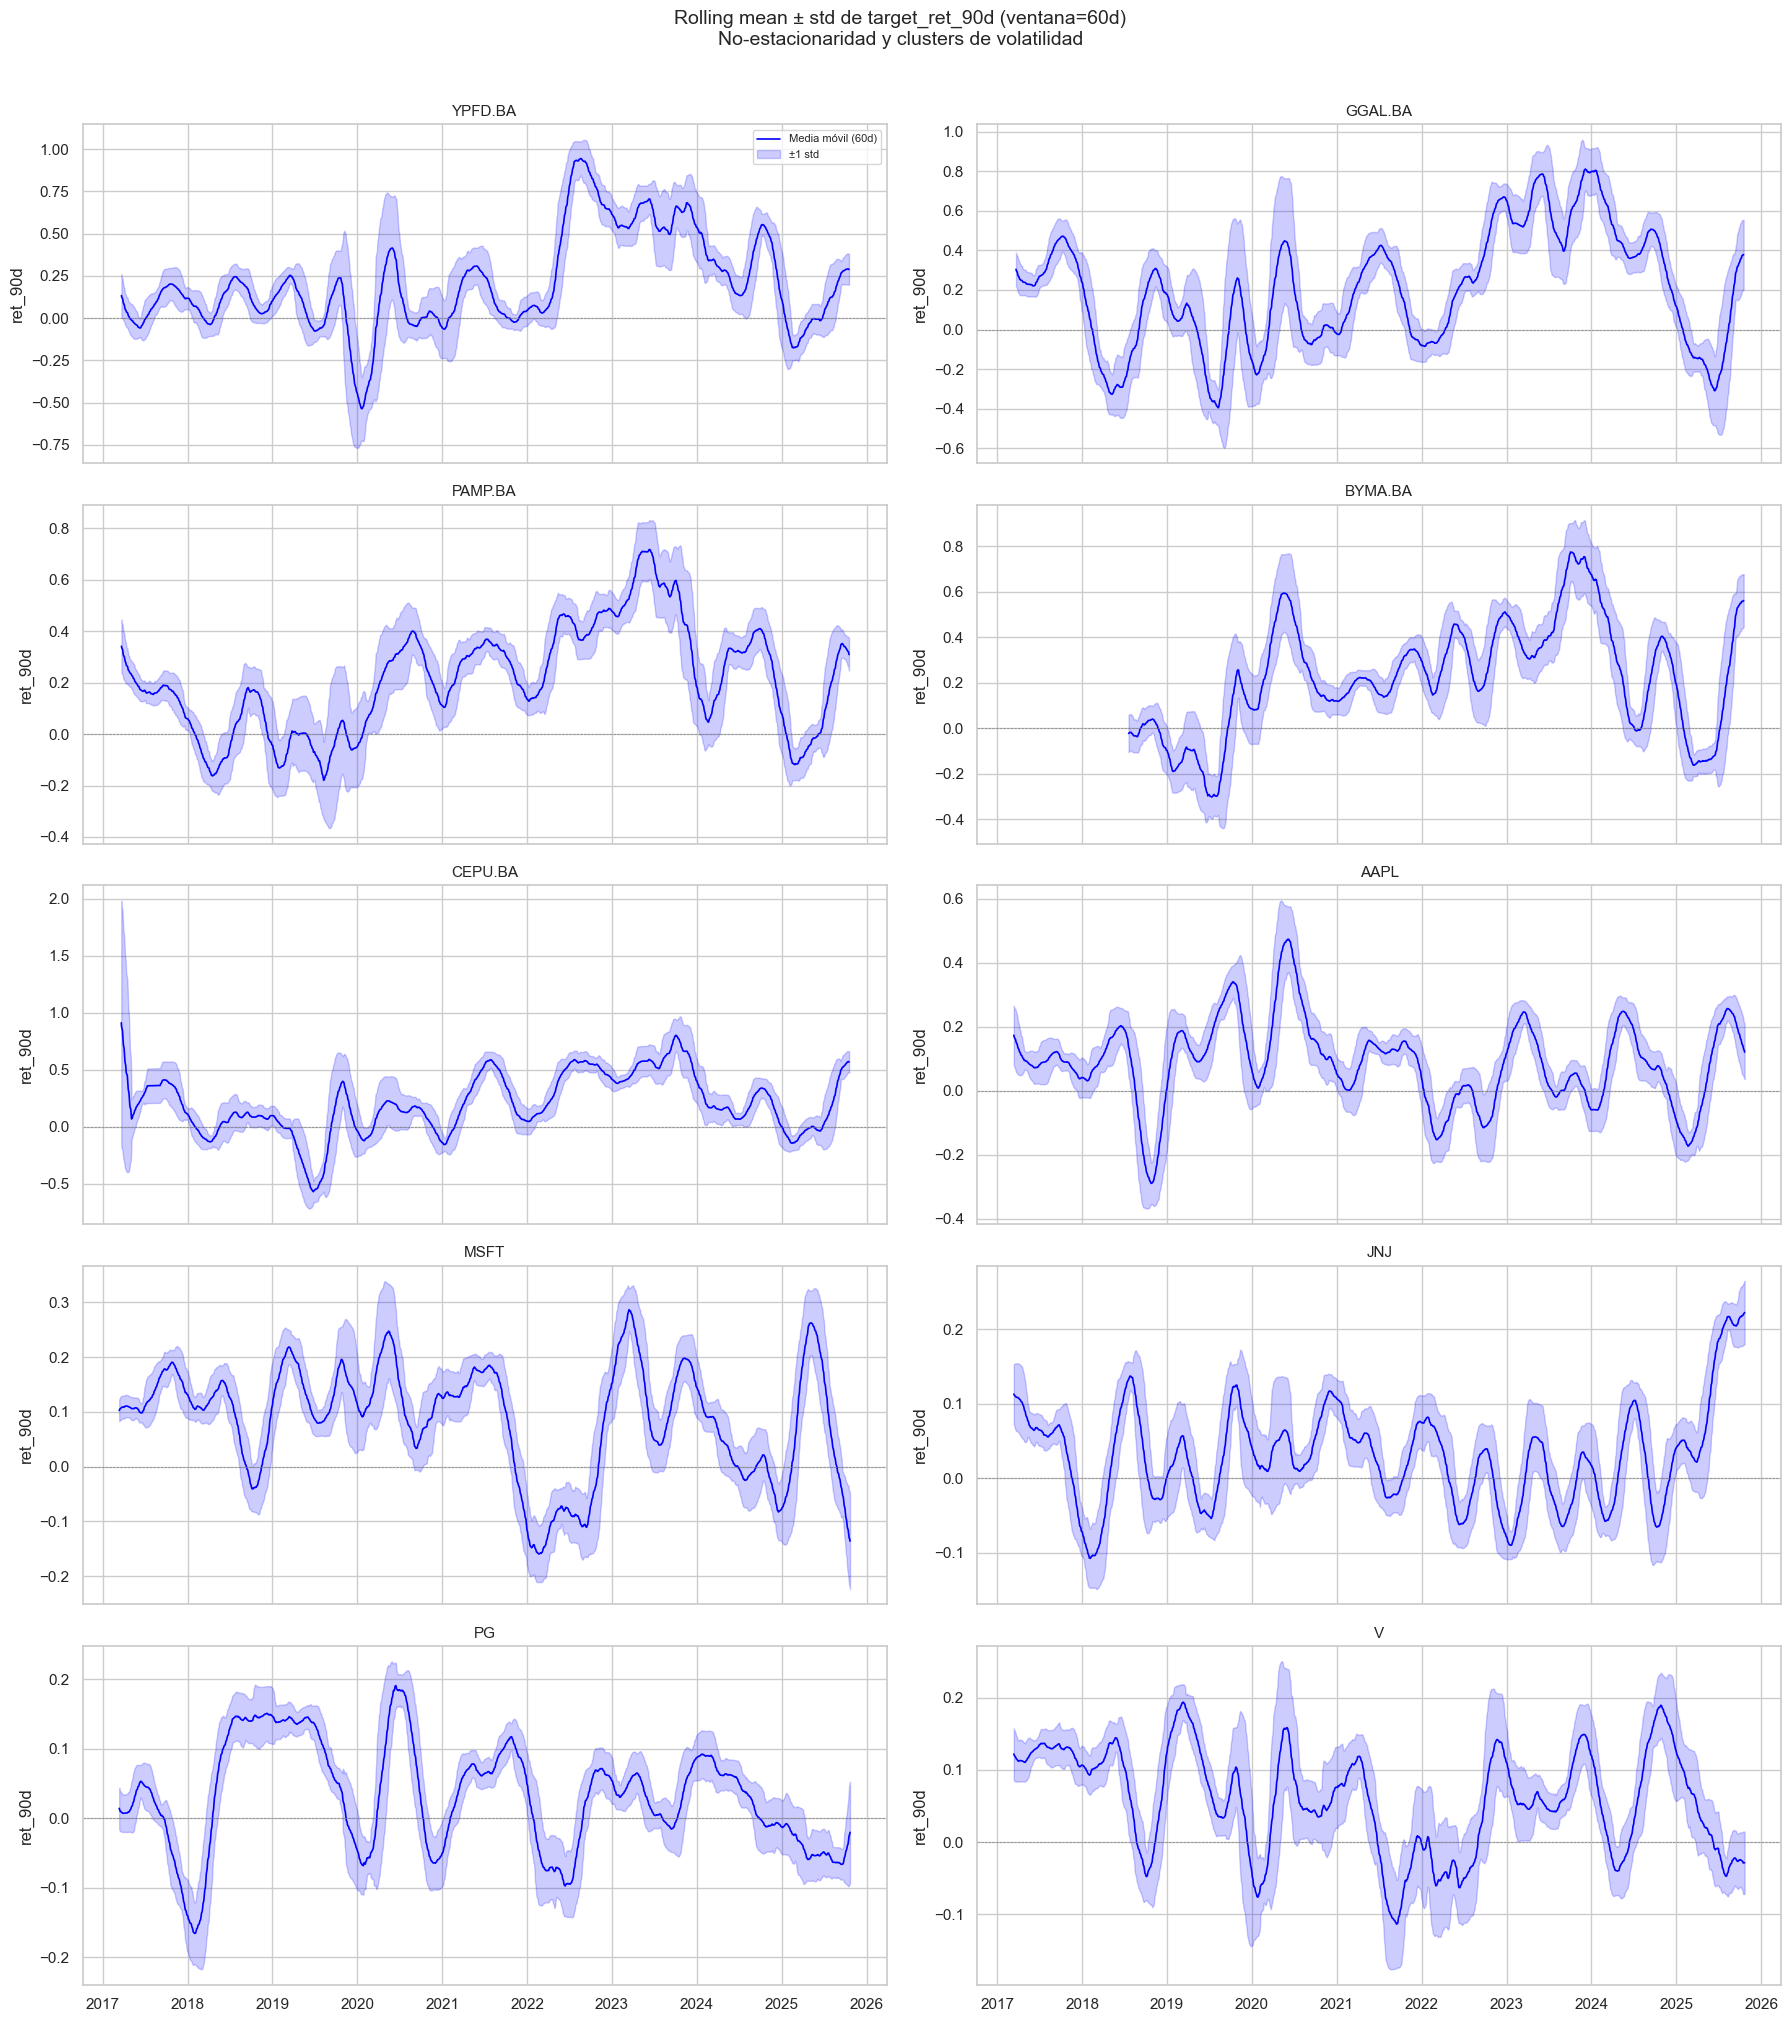

In [37]:
# --- Rolling mean and std of the target ---
# "Rolling" = compute a statistic over a sliding window of N days.
# This shows how the mean and volatility of the target change over time.
# If mean and std were constant, the series would be "stationary".
# In practice they move a lot -> the target is NOT stationary.

ROLLING_W = 60  # 60-day window (~3 months)

fig, axes = plt.subplots(5, 2, figsize=(18, 20), sharex=True)
axes = axes.flatten()

for i, ticker in enumerate(E1_TICKERS):
    if ticker not in targets_all:
        continue
    ax = axes[i]
    tgt = targets_all[ticker]

    # Rolling mean: average target over the last 60 days
    # Rising -> we are in a bullish period. Falling -> bearish.
    roll_mean = tgt.rolling(ROLLING_W).mean()
    # Rolling standard deviation: target volatility over the last 60 days
    # Wide band = high uncertainty. Narrow band = stable market.
    roll_std = tgt.rolling(ROLLING_W).std()

    # Blue line: rolling mean
    ax.plot(roll_mean.index, roll_mean.values, color="blue", linewidth=1.2,
            label=f"Rolling mean ({ROLLING_W}d)")
    # Shaded blue band: mean +/- 1 standard deviation
    # Covers ~68% of the observations if the distribution were normal
    ax.fill_between(roll_mean.index,
                    (roll_mean - roll_std).values,
                    (roll_mean + roll_std).values,
                    alpha=0.2, color="blue", label="±1 std")
    ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")
    ax.set_title(f"{ticker}", fontsize=11)
    ax.set_ylabel(f"ret_{HORIZON}d")
    if i == 0:
        ax.legend(fontsize=8)

fig.suptitle(f"Rolling mean ± std of {target_name} (window={ROLLING_W}d)\n"
             f"Non-stationarity and volatility clusters",
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


**Analysis — Rolling mean and std of the target**

The rolling mean plots with the ±1 std band confirm the **non-stationarity** of the target:

- **Time-varying mean**: the mean of the 90-day return is not constant. It swings between strongly positive (bull markets) and negative (bear markets) values. There is no "global" mean that represents the process at all times.
- **Time-varying volatility** (clusters): high-volatility periods (wide bands) alternate with low-volatility ones (narrow bands). This is known as **volatility clustering** and is a universal property of financial series.
- **AR vs US difference**: AR tickers show wider bands and a higher mean (inflation effect). US tickers show narrower bands with the mean oscillating closer to zero.
- **COVID-2020**: visible as a volatility spike (bands widen abruptly) followed by a compression, on every ticker.

**Implication for the model**:
1. Non-stationarity confirms that a model trained on one regime can fail on another. **Walk-forward** with sliding windows mitigates this by retraining periodically.
2. The time-varying volatility suggests model predictions will be more reliable in low-volatility periods and less reliable in turbulent ones.


---
## 4. Statistical Summary


### 4.1 Statistics table by ticker


In [38]:
# --- Summary table of statistics by ticker ---
# Computes descriptive metrics for daily returns and for the target (90d).
# This makes the differences between tickers and markets quantitatively comparable.

summary_rows = []
for ticker in E1_TICKERS:
    if ticker not in data:
        continue
    df = data[ticker]
    log_ret = np.log(df["close"]).diff().dropna()  # Daily returns
    tgt = targets_all.get(ticker)

    # Jarque-Bera test: tests the hypothesis "the data is normal"
    # If p < 0.05 -> we reject normality (the data is NOT normal)
    # In finance p is ~0 practically always (returns are never normal)
    jb_stat, jb_p = stats.jarque_bera(log_ret)

    row = {
        "Ticker": ticker,
        "Market": "AR" if ticker.endswith(".BA") else "US",
        "N obs": len(df),
        # --- Daily return statistics ---
        "Daily ret μ": f"{log_ret.mean():.5f}",      # Average daily return
        "Daily ret σ": f"{log_ret.std():.4f}",        # Daily volatility
        "Skewness": f"{stats.skew(log_ret):.2f}",      # Asymmetry (<0 = more severe drops)
        "Kurtosis (exc)": f"{stats.kurtosis(log_ret):.1f}",  # Fat tails (>0 = more extremes)
        "JB p-value": f"{jb_p:.1e}",                    # Normality test (p<0.05 -> not normal)
    }

    if tgt is not None:
        row.update({
            # --- Target statistics (90-day return) ---
            "Target μ": f"{tgt.mean():.4f}",    # Average 90d return
            "Target σ": f"{tgt.std():.4f}",      # Target volatility
            "Target min": f"{tgt.min():.3f}",    # Worst 90d return observed
            "Target max": f"{tgt.max():.3f}",    # Best 90d return observed
        })

    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)

# Displaying the DataFrame directly avoids the "<pandas.io.formats.style.Styler ...>" message
display(summary_df)


,Ticker,Mercado,N obs,Ret diario μ,Ret diario σ,Skewness,Kurtosis (exc),JB p-value,Target μ,Target σ,Target min,Target max
0,YPFD.BA,AR,2431,0.00214,0.0336,-0.04,9.8,0.0e+00,0.2122,0.3197,-1.176,1.242
1,GGAL.BA,AR,2432,0.00206,0.0367,-2.14,40.9,0.0e+00,0.2080,0.3338,-0.593,1.040
2,PAMP.BA,AR,2432,0.00243,0.0333,-2.15,44.4,0.0e+00,0.2155,0.2359,-0.453,0.946
3,BYMA.BA,AR,2113,0.00258,0.0324,-2.17,49.5,0.0e+00,0.2234,0.2803,-0.585,1.093
4,CEPU.BA,AR,2396,0.00324,0.0568,20.05,755.9,0.0e+00,0.2259,0.3697,-0.780,2.179
5,AAPL,US,2514,0.00097,0.0182,-0.08,6.8,0.0e+00,0.0882,0.1556,-0.417,0.645
6,MSFT,US,2514,0.00086,0.0169,-0.27,8.3,0.0e+00,0.0842,0.1196,-0.286,0.409
7,JNJ,US,2514,0.00044,0.0115,-0.46,10.2,0.0e+00,0.0332,0.0838,-0.200,0.286
8,PG,US,2514,0.00037,0.0118,-0.08,11.0,0.0e+00,0.0309,0.0868,-0.238,0.309
9,V,US,2514,0.00061,0.0153,-0.15,10.3,0.0e+00,0.0576,0.0902,-0.277,0.359


**Analysis — Statistics table**

The table quantitatively confirms the earlier observations:

- **Mean daily return**: AR (~0.002-0.003) > US (~0.0004-0.001). Argentine tickers have a larger positive drift, dominated by inflation/devaluation.
- **Daily volatility**: AR (3.2-5.7%) > US (1.2-1.8%). CEPU.BA is the most volatile (5.7%), JNJ the least (1.2%).
- **Universal non-normality**: Jarque-Bera p=0.0 for every ticker. None passes the normality test.
- **Kurtosis**: all of them have excess kurtosis > 6, indicating fat tails. AR tickers are particularly leptokurtic (especially CEPU with ku=756.6).
- **90-day target**: the dispersion (σ) of the AR target (0.24-0.38) is 2-4x larger than the US one (0.08-0.16). Predicting returns for Argentine tickers is therefore inherently harder.


### 4.2 Cross-ticker feature heatmap


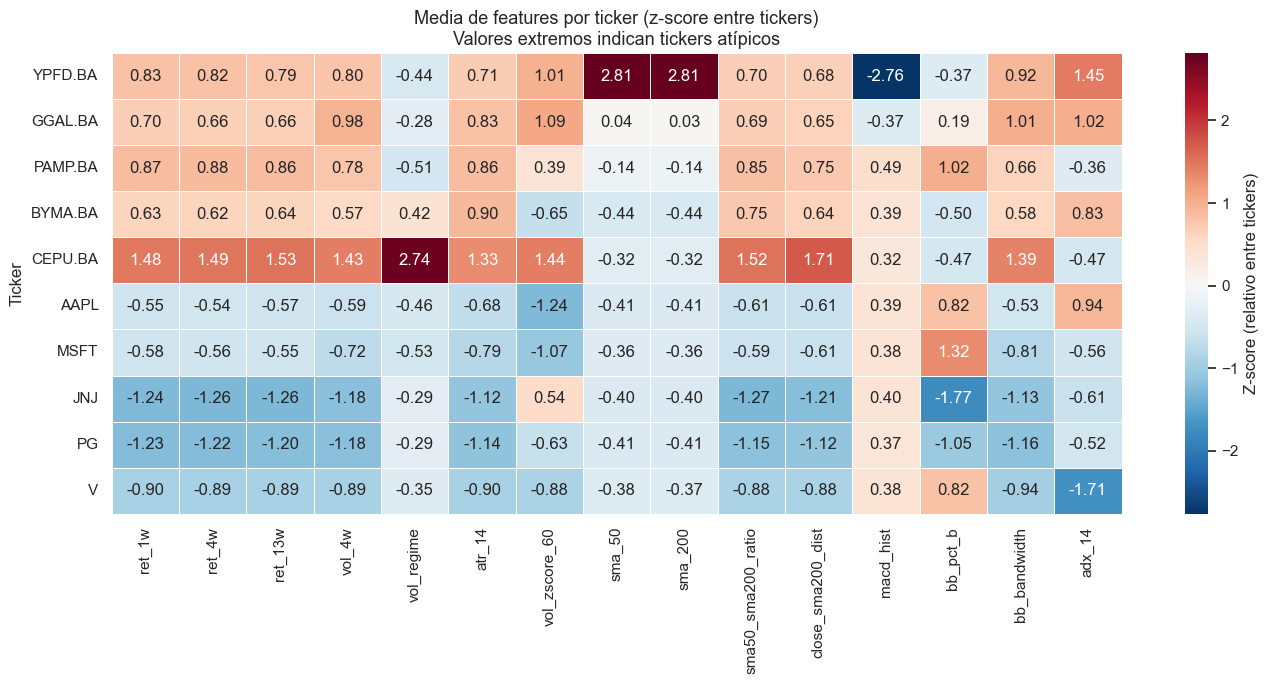

In [39]:
# --- Cross-ticker heatmap: mean of each feature per ticker ---
# Each cell shows the mean of one feature for one ticker.
# Since features live on very different scales (e.g. sma_200 ~ 100-500 vs bb_pct_b ~ 0-1),
# we standardize per column (z-score across tickers) to make them visually comparable.
# Z-score = (value - mean_across_tickers) / std_across_tickers
# Extreme values (|z| > 2) mark tickers that behave very differently from the group.

# Mean of each feature for each ticker
feat_means = pd.DataFrame({
    ticker: features_all[ticker].mean()
    for ticker in E1_TICKERS if ticker in features_all
}).T  # Transpose: rows=tickers, columns=features

# Standardize per column (z-score across tickers, not across features)
# This is what makes atypical tickers stand out feature by feature
feat_means_z = (feat_means - feat_means.mean()) / (feat_means.std() + 1e-12)

fig, ax = plt.subplots(figsize=(14, 7))
# cmap="RdBu_r": red = positive z-score (above the group average)
#                blue = negative z-score (below the group average)
sns.heatmap(feat_means_z, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            ax=ax, linewidths=0.5, cbar_kws={"label": "Z-score (relative across tickers)"})
ax.set_title("Feature means by ticker (z-score across tickers)\n"
             "Extreme values mark atypical tickers", fontsize=13)
ax.set_ylabel("Ticker")
plt.tight_layout()
plt.show()


---
## 5. EDA Conclusions

### 5.1 Global analysis (full E1 universe)

1. **Non-normal distributions and fat tails**
   - Normality is rejected on every ticker (Jarque-Bera p-value ~0), with extreme events more frequent than expected under a normal.
   - This supports using a robust loss (Huber) and a non-linear model (GRU).

2. **Non-stationarity of the 90-day target**
   - The mean and variance of the target change over time (regimes), so a fixed time split is not enough.
   - The walk-forward approach with periodic retraining is consistent with that dynamic.

3. **Mechanical autocorrelation of the target**
   - The high autocorrelation observed is explained by the overlapping 90-day forward windows.
   - The 90-day embargo is necessary and coherent to avoid train-test dependency.

4. **Multicollinearity and feature set simplification (per 2.2)**
   - These features were explicitly removed as redundant:
     - `close_sma200_dist`
     - `vol_4w`
     - `sma_200`
   - The set is now more parsimonious without losing key structural signal.

### 5.2 Market analysis: Argentina (.BA)

1. **Higher nominal return level and higher volatility**
   - AR tickers show higher returns and dispersion, consistent with the inflationary/devaluation context.

2. **Risk of spurious correlations from the nominal scale**
   - Part of the feature-target relationships in AR may be inflated by nominal price dynamics.
   - That is why keeping per-ticker normalization (not pooled) in training and evaluation is key.

3. **More extremes**
   - There is evidence of fatter tails and more pronounced stress episodes in AR, with potential impact on the stability of per-fold metrics.

### 5.3 Market analysis: United States (US)

1. **Lower volatility and more stable behavior**
   - In the US the return scale and dispersion are lower than in AR, with more regular paths.

2. **More moderate linear signals**
   - Feature-target correlations do exist but are generally more contained, consistent with a more efficient market.

3. **Value of the robust temporal approach**
   - Although more stable than AR, the US also goes through regime changes; that is why walk-forward validation stays necessary.

### 5.4 Modelling recommendations

- Keep the feature set cleaned up after 2.2 and document explicitly that `close_sma200_dist`, `vol_4w` and `sma_200` were removed.
- Keep per-ticker Z-score normalization on features and target to avoid scale bias across markets.
- Monitor tickers with extreme behavior (e.g. CEPU.BA) in per-fold metrics and error analysis.
- Prioritize out-of-sample robustness (walk-forward + embargo) over marginal in-sample gains.
